In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import ast

import matplotlib.dates as mdates
import matplotlib.font_manager as fm


In [2]:
# ==========================================
# 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# ==========================================

# 1. leer ambos datasets
pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

# 2. interpretar estilo de HOSPIS
# Transformamos los colores (que vienen como texto) a tuplas de Python
hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
# Traducimos las formas al lenguaje de Matplotlib ('dot' -> 'o', 'star' -> '*')
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

# 3. Renombramos columnas de PACIENTES para que sean más descriptivas
pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',

    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',

    'Sexo': 'sexo',
    'Edad': 'edad',

    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',

    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',

    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',

    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',

    'Asistencia Respiratoria Mecánica': 'requiere_arm',

    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',

    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',

    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

# 4. corregir errores de ortografia
pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})


# 5. Convertimos a datetime para poder operar con tiempos
pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')

# 6. Ordenamos PACIENTES por paciente y fecha de ingreso para reconstruir la historia
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. DF AUXILIAR: INCONSISTENCIAS DE ID (Comentado)
# ==========================================
"""
# Detecta IDs que tienen más de una edad o más de un sexo registrado
inconsistencias = df_clean.groupby('paciente_id').agg(
    cant_edades=('Edad', lambda x: x.dropna().nunique()),
    cant_sexos=('Sexo', lambda x: x.dropna().nunique())
)
ids_problematicos = inconsistencias[(inconsistencias['cant_edades'] > 1) | (inconsistencias['cant_sexos'] > 1)].index

# DataFrame con los casos raros para revisar después
df_edades_inconsistentes = df_clean[df_clean['paciente_id'].isin(ids_problematicos)].copy()
"""


# # ==========================================
# # 3. CONSTRUCCIÓN DE TRASLADOS (El core del modelo)
# # ==========================================

# 7. Asocia los traslados con la fila de abajo
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos' # ASUNCION: si la fecha da -1 es por un error en el sistema de carga de datos
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0


# 8. Definimos qué motivos consideramos como "traslado" real
motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']

# 9. Filtramos: 
#   1. Que haya un destino
#   2. Que el motivo sea de traslado
#   3. (Opcional) Que origen y destino sean distintos # ASUNCION

mask_traslados = (
    pacientes['hospital_destino'].notna() & # 1
    pacientes['motivo_egreso'].isin(motivos_validos) & # 2
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) # 3
)
df_potenciales = pacientes[mask_traslados].copy()  #aplicamos el filtro


# # ==========================================
# # 4. MANEJO DE TIEMPOS (> 30 días y Alertas)
# # ==========================================

# A. DF Auxiliar: Traslados que tardaron MÁS de 30 días (para consultar/auditar)
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()

# B. DF Principal de Traslados (<= 100 días)
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
#print(df_traslados.columns)
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})
# Marcamos la alerta (Ejemplo: Si el traslado tardó más de 3 días, es una alerta) # LO VAMOS A TRABAJAR EN EL FUTURO
df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# # ==========================================
# # 5. DF DE TRAYECTORIAS (Reconstrucción completa)
# # ==========================================

# 10. Trayectorias para recorrido. Mas que nada en el futuro: 
# Agrupamos por paciente en la base de traslados válidos para ver su "viaje"
def armar_trayectoria(group):
    # Secuencia de hospitales: [Origen1, Destino1(que es Origen2), Destino2, ...]
    # Tomamos todos los orígenes y le sumamos el último destino para tener la ruta completa
    ruta = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    
    # Juntamos los días de alerta en un array/lista (solo guardamos los > 0 para que sea limpio)
    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales': " -> ".join(ruta),
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

# Solo armamos trayectoria de los que tuvieron al menos un traslado exitoso (<= 30 días)
df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()

# Mostramos cómo quedaron (opcional)
# print("Traslados listos para el grafo:", len(df_traslados))
# print("Traslados anómalos (>30 días):", len(df_mas_30_dias))
#display(df_trayectoria.head())

df_traslados
pacientes

,hospital_id,hospital_origen,paciente_id,fecha_ingreso,estado_ingreso,tipo_ingreso,estado_ultimo,tipo_ultimo,sexo,edad,...,operacion,fecha_egreso,fecha_ultima_actualizacion,paso_criticas,paso_intermedias,paso_generales,hospital_destino,fecha_ingreso_destino,dias_traslado,eror_fechas
0,147,UPA 17 - QU,1,2020-05-01 12:11:27,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,36,...,egreso,2020-08-03 12:11:27,2020-08-04 15:05:01,no,si,no,Oñativia,2020-05-19 12:11:20,-77.0,NaN
1,8,Oñativia,1,2020-05-19 12:11:20,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,44,...,egreso,2020-06-05 12:11:20,2020-07-21 14:34:48,no,si,no,UPA 10 - BE,2020-06-07 12:11:28,2.0,NaN
2,148,UPA 10 - BE,1,2020-06-07 12:11:28,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,NaN,...,egreso,2020-06-08 12:11:28,2020-07-21 14:34:52,no,si,no,NaN,NaT,NaN,NaN
3,147,UPA 17 - QU,2,2020-04-06 12:11:27,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,59,...,egreso,2020-06-23 12:11:27,2020-07-21 14:34:52,no,si,no,Oñativia,2020-05-29 12:11:19,-26.0,NaN
4,8,Oñativia,2,2020-05-29 12:11:19,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,28,...,egreso,2020-06-11 12:11:19,2020-07-21 14:34:48,no,si,no,NaN,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29692,10,Evita Pueblo,ZZ94,2021-07-30 12:11:23,ocupadas_otros,criticas,ocupadas_otros,criticas,femenino,53,...,egreso,2021-07-30 12:11:23,2021-07-31 17:16:48,si,no,no,NaN,NaT,NaN,NaN
29693,5,Iriarte,ZZ98,2022-02-08 12:11:13,ocupadas_otros,criticas,ocupadas_otros,generales,masculino,38,...,NaN,NaT,2022-03-04 08:38:43,si,no,si,NaN,NaT,NaN,NaN
29694,145,UPA 5 - AB,ZZ99,2022-07-05 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,66,...,egreso,2022-07-06 12:11:25,2022-07-07 08:24:13,no,si,no,Módulo Hospitalario 9 - AB,2022-07-06 12:11:21,0.0,Error de carga de datos
29695,9,Módulo Hospitalario 9 - AB,ZZ99,2022-07-06 12:11:21,ocupadas_otros,criticas,ocupadas_otros,criticas,femenino,66,...,egreso,2022-07-07 12:11:21,2022-07-12 09:38:20,si,no,no,NaN,NaT,NaN,NaN


In [3]:
# paciente_testigo = 'WN04'
# display(pacientes[pacientes['paciente_id'] == paciente_testigo][['fecha_ingreso', 'hospital_origen', 'motivo_egreso', 'fecha_egreso', 'hospital_destino', 'dias_traslado', 'riesgo_clinico']])

# # Ver las 5 trayectorias con más traslados
# display(df_trayectoria.sort_values('cantidad_traslados', ascending=False).head(5))

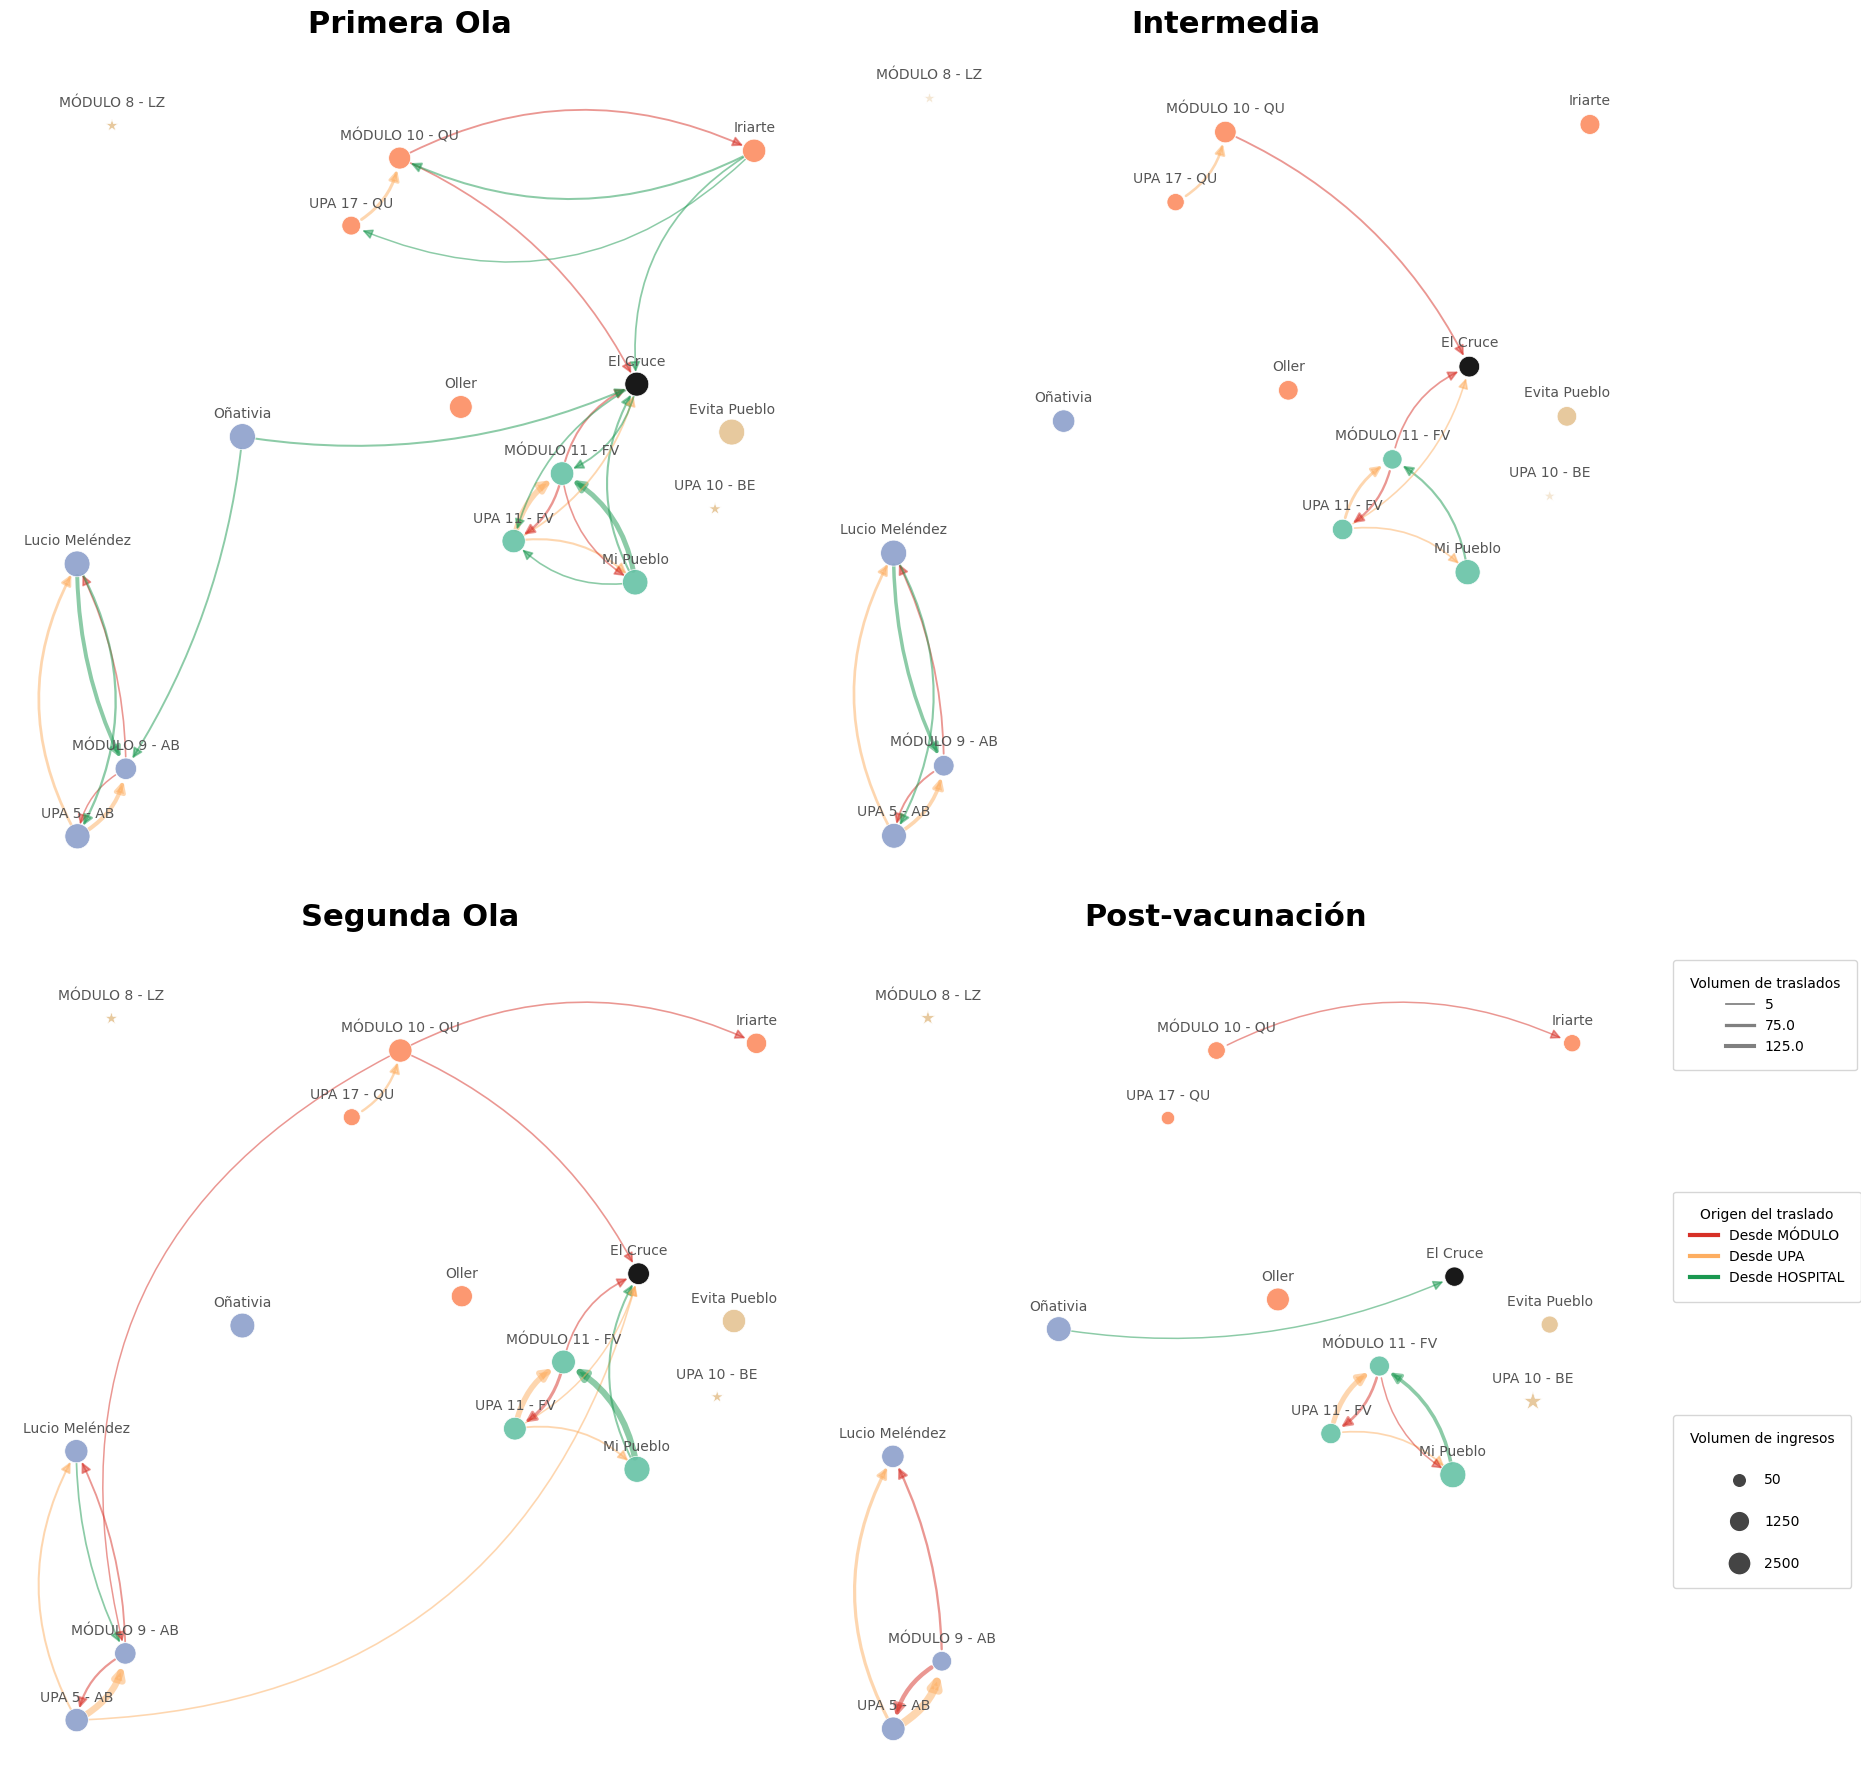

In [4]:
# ==========================================
# 3. PREPARACIÓN DE COORDENADAS
# ==========================================
df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
    # No renombramos 'color' y 'shape' porque ya tienen buenos nombres
})

# Separación de hospitales con mismas coordenadas
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []

for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        primeras = True
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if primeras:
                primeras = False
            else:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
# --- AJUSTE MANUAL DE POSICIONES PARA VISIBILIDAD ---
# Módulo 8 - LZ: Lo movemos a la derecha (sumamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.07
# UPA 10 - BE: Lo movemos a la izquierda (restamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.08
# EVITA PUEBLO: Lo movemos a la izquierda (restamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.04

# Traductor de formas para NetworkX
mapa_formas = {
    'dot': 'o',   # Círculo
    'star': '*'   # Estrella
}

# ==========================================
# 4. CONFIGURACIÓN VISUAL
# ==========================================
periodos = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]

# ==========================================
# 5. CÁLCULOS GLOBALES Y ESCALAS (PREVIO AL DIBUJO)
# ==========================================
# Constantes de diseño ajustadas para Raíz Cuadrada
MIN_GROSOR_ARISTA = 0.5
MAX_GROSOR_ARISTA = 8.0
MIN_TAMANO_NODO = 80     
MAX_TAMANO_NODO = 350   

hospitales_conocidos = set(df_coordenadas['hospital'])

# Cálculos globales para referencias y leyendas
agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
MAX_TRASLADOS_GLOBAL = agrupado_global.max() if not agrupado_global.empty else 1
pesos_filtrados = agrupado_global[agrupado_global > 4]

if not pesos_filtrados.empty:
    min_t = int(pesos_filtrados.min())
    med_t = int(np.median(pesos_filtrados))
    max_t = int(pesos_filtrados.max())
else:
    min_t, med_t, max_t = 3, 5, 10

ingresos_globales = pacientes['hospital_origen'].value_counts()
MAX_INGRESOS_GLOBAL = ingresos_globales.max() if not ingresos_globales.empty else 1
ingresos_filtrados = ingresos_globales[ingresos_globales > 0]

if not ingresos_filtrados.empty:
    min_i = int(ingresos_filtrados.min())
    med_i = int(np.median(ingresos_filtrados))
    max_i = int(ingresos_filtrados.max())
else:
    min_i, med_i, max_i = 10, 50, 100

def calc_grosor(peso):
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

def calc_markersize(ingreso):
    escala = np.sqrt(ingreso) / np.sqrt(MAX_INGRESOS_GLOBAL) if MAX_INGRESOS_GLOBAL > 0 else 0
    area = MIN_TAMANO_NODO + (escala * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return np.sqrt(area)

# ==========================================
# 6. DIBUJO DEL GRÁFICO (GRILLA 2x2 - ESTILO ACTUALIZADO)
# ==========================================

def asignar_color_tipo(nombre_hospital):
    nombre_norm = nombre_hospital.upper()
    if 'MODULO' in nombre_norm or 'MÓDULO' in nombre_norm:
        return '#d73027'  # Rojo
    elif 'UPA' in nombre_norm:
        return '#fdae61'  # Naranja
    else:
        return '#1a9850'  # Verde

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

# Para las leyendas finales, guardaremos los valores máximos encontrados en todos los periodos
v_max_encontrado = 0
i_max_encontrado = 0

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes_flat[idx]
    ax.set_title(titulo, fontsize=22, fontweight='bold', pad=20)
    
    # 1. FILTRADO
    mask_ingresos = (pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)
    ingresos_periodo_ser = pacientes[mask_ingresos]['hospital_origen'].value_counts()
    ingresos_por_hospital = ingresos_periodo_ser.to_dict()
    
    mask_tras = (df_traslados['fecha_egreso'] >= inicio) & (df_traslados['fecha_egreso'] <= fin)
    df_periodo_traslados = df_traslados[mask_tras].copy()
    traslados_agrupados = df_periodo_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
    
    # Traslados visibles (> 4)
    traslados_dibujables = traslados_agrupados[traslados_agrupados['peso'] > 2]
    
    # Actualizar máximos para la leyenda global
    if not traslados_dibujables.empty:
        v_max_encontrado = max(v_max_encontrado, traslados_dibujables['peso'].max())
    if not ingresos_periodo_ser.empty:
        i_max_encontrado = max(i_max_encontrado, ingresos_periodo_ser.max())

    G = nx.DiGraph()

# 2. AÑADIR NODOS
    for _, row in df_coordenadas.iterrows():
        h = row['hospital']
        n_ing = ingresos_por_hospital.get(h, 0)
        
        # Escala basada en el máximo del periodo actual
        escala_n = np.sqrt(n_ing) / np.sqrt(ingresos_periodo_ser.max()) if not ingresos_periodo_ser.empty and n_ing > 0 else 0
        tamano_nodo = MIN_TAMANO_NODO + (escala_n * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
        
        try: color_rgb = ast.literal_eval(str(row['color']))
        except: color_rgb = 'grey'
            
        forma_nodo = mapa_formas.get(row['shape'], 'o')
        
        # --- CAMBIO 1: Subimos el alpha de 0.05 a 0.4 para que los nodos inactivos se vean ---
        alpha_val = 0.9 if n_ing > 0 else 0.4
        
        G.add_node(h, pos=(row['lon'], row['lat']), color=color_rgb, size=tamano_nodo, shape=forma_nodo, alpha=alpha_val)

    # 3. AÑADIR ARISTAS
    for _, row_t in traslados_dibujables.iterrows():
        u, v = row_t['hospital_ingreso'], row_t['hospital_destino']
        if u in hospitales_conocidos and v in hospitales_conocidos:
            G.add_edge(u, v, weight=row_t['peso'])

    posiciones = nx.get_node_attributes(G, 'pos')
    
    # 4. DIBUJAR
    formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
    for forma in formas_presentes:
        nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        nx.draw_networkx_nodes(G, posiciones, nodelist=nodelist, ax=ax, 
                               node_shape=forma, 
                               node_color=[G.nodes[n]['color'] for n in nodelist], 
                               node_size=[G.nodes[n]['size'] for n in nodelist], 
                               alpha=[G.nodes[n]['alpha'] for n in nodelist],
                               edgecolors='white', linewidths=0.5)

    for u, v, data in G.edges(data=True):
        peso = data['weight']
        escala_peso = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
        grosor = MIN_GROSOR_ARISTA + (escala_peso * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

        color_flecha = asignar_color_tipo(u)
    
        suma_caracteres = sum(ord(c) for c in u + v)
        rad_dinamico = (suma_caracteres % 85 - 35) / 100.0
        if abs(rad_dinamico) < 0.12: rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        nx.draw_networkx_edges(G, posiciones, edgelist=[(u, v)], ax=ax,
                                width=grosor, edge_color=color_flecha, alpha=0.5,
                                arrowstyle='-|>', arrowsize=15, 
                                connectionstyle=f"arc3,rad={rad_dinamico}")

    # --- CAMBIO 2: Quitamos el "if" para que TODOS los nodos del mapa tengan su etiqueta ---
    labels = {n: n.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO') 
              for n in G.nodes()}
    pos_labels = {k: (v[0], v[1] + 0.005) for k, v in posiciones.items() if k in labels}
    
    # Le bajamos un poquito el color a las letras (#555555) para que no sature el mapa con tanto texto
    nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=10, font_color='#555555')

    ax.axis('off')
    
# ==========================================
# 7. LEYENDAS MANUALES (PONER AQUÍ)
# ==========================================

# 1. Definimos el eje de referencia (el último de la grilla)
ax_ref = axes_flat[-1] 

# 2. Creamos los objetos "Proxy" (No dibujan nada en el mapa, solo existen para la leyenda)
# Usamos los máximos reales que calculamos durante el bucle


# v_min_leg = 5
# v_max_leg = int(v_max_encontrado)
# v_med_leg = int(((np.sqrt(v_min_leg) + np.sqrt(v_max_leg)) / 2) ** 2)

# Función para redondear a números "humanos" (10, 50, 100...)
def redondear_estetico(valor):
    if valor <= 10: return 10
    if valor <= 100: return int(np.ceil(valor / 10) * 10)
    return int(np.ceil(valor / 50) * 50)

# --- Para los Traslados (Grosor) ---
v_max_leg = redondear_estetico(v_max_encontrado)
v_min_leg = 5  # Mantenemos el umbral mínimo que definiste
v_med_leg = redondear_estetico((v_min_leg + v_max_leg) / 2)

# --- Para los Ingresos (Tamaño Nodo) ---
i_max_leg = redondear_estetico(i_max_encontrado)
i_min_leg = 50 
i_med_leg = redondear_estetico(i_max_leg / 2)



# --- Referencias de Volumen (Grosor) ---
lineas_volumen = [
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_min_leg), label=f'{v_min_leg}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_med_leg)/2, label=f'{v_med_leg/2}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_max_leg)/2, label=f'{v_max_leg/2}')
]

# --- Referencias de Origen (Color) ---
lineas_colores = [
    mlines.Line2D([], [], color='#d73027', lw=3, label='Desde MÓDULO'),
    mlines.Line2D([], [], color='#fdae61', lw=3, label='Desde UPA'),
    mlines.Line2D([], [], color='#1a9850', lw=3, label='Desde HOSPITAL')
]

# # --- Referencias de Ingresos (Tamaño de Nodo) ---
# i_min_leg = 10
# i_max_leg = int(i_max_encontrado)
# i_med_leg = int(((np.sqrt(i_min_leg) + np.sqrt(i_max_leg)) / 2) ** 2)

nodos_ingresos = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_min_leg), label=f'{i_min_leg}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_med_leg), label=f'{i_med_leg}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_max_leg), label=f'{i_max_leg}')
]

# 3. Agregamos las leyendas al eje usando bbox_to_anchor para que floten a la derecha
leg1 = ax_ref.legend(handles=lineas_volumen, title="Volumen de traslados", 
                     loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True, borderpad=1.2)
ax_ref.add_artist(leg1)

leg2 = ax_ref.legend(handles=lineas_colores, title="Origen del traslado", 
                     loc='upper left', bbox_to_anchor=(1.05, 0.72), frameon=True, borderpad=1.2)
ax_ref.add_artist(leg2)

leg3 = ax_ref.legend(handles=nodos_ingresos, title="Volumen de ingresos", 
                     loc='upper left', bbox_to_anchor=(1.05, 0.45), frameon=True, borderpad=1.2, labelspacing=2)

# 4. AJUSTE FINAL DE LA FIGURA
plt.tight_layout(rect=[0, 0, 0.85, 1]) # El 0.85 deja el 15% derecho libre para las leyendas
plt.show()

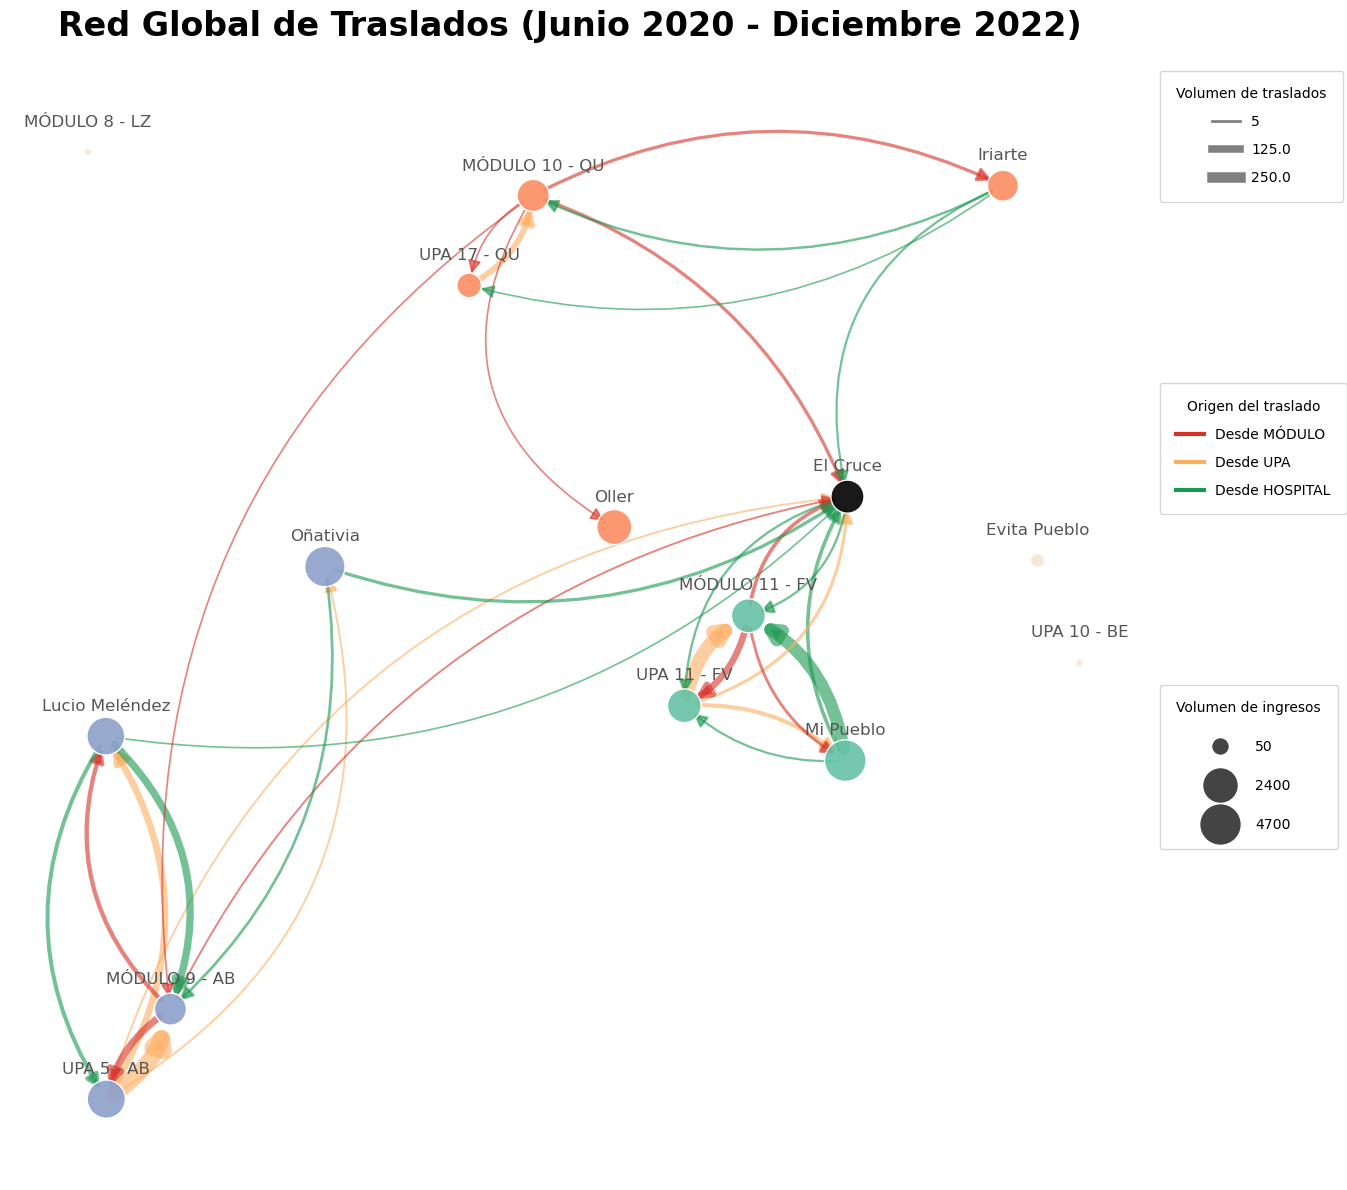

In [5]:
# ==========================================
# 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# ==========================================

# 1. leer ambos datasets
pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

# 2. interpretar estilo de HOSPIS
# Transformamos los colores (que vienen como texto) a tuplas de Python
hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
# Traducimos las formas al lenguaje de Matplotlib ('dot' -> 'o', 'star' -> '*')
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

# 3. Renombramos columnas de PACIENTES para que sean más descriptivas
pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',

    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',

    'Sexo': 'sexo',
    'Edad': 'edad',

    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',

    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',

    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',

    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',

    'Asistencia Respiratoria Mecánica': 'requiere_arm',

    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',

    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',

    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

# 4. corregir errores de ortografia
pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})


# 5. Convertimos a datetime para poder operar con tiempos
pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')

# 6. Ordenamos PACIENTES por paciente y fecha de ingreso para reconstruir la historia
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. DF AUXILIAR: INCONSISTENCIAS DE ID (Comentado)
# ==========================================
"""
# Detecta IDs que tienen más de una edad o más de un sexo registrado
inconsistencias = df_clean.groupby('paciente_id').agg(
    cant_edades=('Edad', lambda x: x.dropna().nunique()),
    cant_sexos=('Sexo', lambda x: x.dropna().nunique())
)
ids_problematicos = inconsistencias[(inconsistencias['cant_edades'] > 1) | (inconsistencias['cant_sexos'] > 1)].index

# DataFrame con los casos raros para revisar después
df_edades_inconsistentes = df_clean[df_clean['paciente_id'].isin(ids_problematicos)].copy()
"""


# # ==========================================
# # 3. CONSTRUCCIÓN DE TRASLADOS (El core del modelo)
# # ==========================================

# 7. Asocia los traslados con la fila de abajo
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos' # ASUNCION: si la fecha da -1 es por un error en el sistema de carga de datos
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0


# 8. Definimos qué motivos consideramos como "traslado" real
motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']

# 9. Filtramos: 
#   1. Que haya un destino
#   2. Que el motivo sea de traslado
#   3. (Opcional) Que origen y destino sean distintos # ASUNCION

mask_traslados = (
    pacientes['hospital_destino'].notna() & # 1
    pacientes['motivo_egreso'].isin(motivos_validos) & # 2
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) # 3
)
df_potenciales = pacientes[mask_traslados].copy()  #aplicamos el filtro


# # ==========================================
# # 4. MANEJO DE TIEMPOS (> 30 días y Alertas)
# # ==========================================

# A. DF Auxiliar: Traslados que tardaron MÁS de 30 días (para consultar/auditar)
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()

# B. DF Principal de Traslados (<= 100 días)
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
#print(df_traslados.columns)
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})
# Marcamos la alerta (Ejemplo: Si el traslado tardó más de 3 días, es una alerta) # LO VAMOS A TRABAJAR EN EL FUTURO
df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# # ==========================================
# # 5. DF DE TRAYECTORIAS (Reconstrucción completa)
# # ==========================================

# 10. Trayectorias para recorrido. Mas que nada en el futuro: 
# Agrupamos por paciente en la base de traslados válidos para ver su "viaje"
def armar_trayectoria(group):
    # Secuencia de hospitales: [Origen1, Destino1(que es Origen2), Destino2, ...]
    # Tomamos todos los orígenes y le sumamos el último destino para tener la ruta completa
    ruta = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    
    # Juntamos los días de alerta en un array/lista (solo guardamos los > 0 para que sea limpio)
    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales': " -> ".join(ruta),
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

# Solo armamos trayectoria de los que tuvieron al menos un traslado exitoso (<= 30 días)
df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()

# Mostramos cómo quedaron (opcional)
# print("Traslados listos para el grafo:", len(df_traslados))
# print("Traslados anómalos (>30 días):", len(df_mas_30_dias))
#display(df_trayectoria.head())
# ==========================================
# 3. PREPARACIÓN DE COORDENADAS (CON AJUSTES MANUALES)
# ==========================================
df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
})

# --- MOVIMIENTOS MANUALES PARA EVITAR CORTES EN MÁRGENES ---
# Módulo 8 - LZ: Lo movemos a la derecha (sumamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06

# UPA 10 - BE: Lo movemos a la izquierda (restamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06

# Evita Pueblo: Lo alejamos un poco del borde derecho
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Procesamiento de duplicados (se mantiene igual)
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []
for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if i > 0:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)

# ==========================================
# 4. CONFIGURACIÓN VISUAL
# ==========================================
periodos = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]

# ==========================================
# 5. CÁLCULOS GLOBALES Y ESCALAS (PREVIO AL DIBUJO)
# ==========================================
# Constantes de diseño ajustadas para Raíz Cuadrada
MIN_GROSOR_ARISTA = 0.5
MAX_GROSOR_ARISTA = 15.0
MIN_TAMANO_NODO = 80     
MAX_TAMANO_NODO = 900   

hospitales_conocidos = set(df_coordenadas['hospital'])

# Cálculos globales para referencias y leyendas
agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
MAX_TRASLADOS_GLOBAL = agrupado_global.max() if not agrupado_global.empty else 1
pesos_filtrados = agrupado_global[agrupado_global > 4]

if not pesos_filtrados.empty:
    min_t = int(pesos_filtrados.min())
    med_t = int(np.median(pesos_filtrados))
    max_t = int(pesos_filtrados.max())
else:
    min_t, med_t, max_t = 3, 5, 10

ingresos_globales = pacientes['hospital_origen'].value_counts()
MAX_INGRESOS_GLOBAL = ingresos_globales.max() if not ingresos_globales.empty else 1
ingresos_filtrados = ingresos_globales[ingresos_globales > 0]

if not ingresos_filtrados.empty:
    min_i = int(ingresos_filtrados.min())
    med_i = int(np.median(ingresos_filtrados))
    max_i = int(ingresos_filtrados.max())
else:
    min_i, med_i, max_i = 10, 50, 100

def calc_grosor(peso):
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

def calc_markersize(ingreso):
    escala = np.sqrt(ingreso) / np.sqrt(MAX_INGRESOS_GLOBAL) if MAX_INGRESOS_GLOBAL > 0 else 0
    area = MIN_TAMANO_NODO + (escala * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return np.sqrt(area)

# ==========================================
# 6. DIBUJO DEL GRÁFICO GLOBAL (DEFINITIVO)
# ==========================================
MIN_TAMANO_NODO_GLOBAL = 150
MAX_TAMANO_NODO_GLOBAL = 900  

MIN_GROSOR_ARISTA_GLOBAL = 0.3
MAX_GROSOR_ARISTA_GLOBAL = 12.0 

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('white')

ax.set_title('Red Global de Traslados (Junio 2020 - Diciembre 2022)', fontsize=24, fontweight='bold', pad=20)

# ---------------------------------------------------------
# 1. FILTRAMOS ESTRICTAMENTE LO QUE SE VA A DIBUJAR
# ---------------------------------------------------------
# Filtramos traslados válidos entre hospitales que tenemos en coordenadas
# Y EXCLUIMOS LOS TRASLADOS A SÍ MISMOS (self-loops)
mask_validos = (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & \
               (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & \
               (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])

df_traslados_validos = df_traslados[mask_validos]
traslados_agrupados_global = df_traslados_validos.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')

# ¡CLAVE! Nos quedamos únicamente con los traslados que superan el umbral visual (> 4)
traslados_dibujables = traslados_agrupados_global[traslados_agrupados_global['peso'] > 2]

# Calculamos el MÁXIMO REAL de las aristas visibles
MAX_TRASLADOS_REAL = traslados_dibujables['peso'].max() if not traslados_dibujables.empty else 1

if not traslados_dibujables.empty:
    min_t_real = int(traslados_dibujables['peso'].min())
    max_t_real = int(traslados_dibujables['peso'].max())
    # Calculamos el valor que da exactamente el grosor intermedio visual
    med_t_real = int(((np.sqrt(min_t_real) + np.sqrt(max_t_real)) / 2) ** 2)
else:
    min_t_real, med_t_real, max_t_real = 3, 5, 10

# Identificamos qué hospitales participan de estas conexiones visibles
hospitales_conectados = set(traslados_dibujables['hospital_ingreso']).union(set(traslados_dibujables['hospital_destino']))

# Filtramos los ingresos SOLO para los hospitales que están conectados en el dibujo
ingresos_globales_ser = pacientes[pacientes['hospital_origen'].isin(hospitales_conectados)]['hospital_origen'].value_counts()
ingresos_por_hospital_global = ingresos_globales_ser.to_dict()

# Calculamos el MÁXIMO REAL de nodos visibles
MAX_INGRESOS_REAL = ingresos_globales_ser.max() if not ingresos_globales_ser.empty else 1

ingresos_reales = ingresos_globales_ser[ingresos_globales_ser > 0]
if not ingresos_reales.empty:
    min_i_real = int(ingresos_reales.min())
    max_i_real = int(ingresos_reales.max())
    # Calculamos el valor que da exactamente el tamaño de círculo intermedio visual
    med_i_real = int(((np.sqrt(min_i_real) + np.sqrt(max_i_real)) / 2) ** 2)
else:
    min_i_real, med_i_real, max_i_real = 10, 50, 100

G = nx.DiGraph()

# ---------------------------------------------------------
# 2. DIBUJAR NODOS
# ---------------------------------------------------------
for _, row in df_coordenadas.iterrows():
    h = row['hospital']
    n_ing = ingresos_por_hospital_global.get(h, 0)
    
    # Si tiene ingresos, escalamos el tamaño. Si no, tamaño mínimo.
    if n_ing > 0:
        escala_n = np.sqrt(n_ing) / np.sqrt(MAX_INGRESOS_REAL)
        tamano_nodo = MIN_TAMANO_NODO_GLOBAL + (escala_n * (MAX_TAMANO_NODO_GLOBAL - MIN_TAMANO_NODO_GLOBAL))
        alpha_val = 0.9  # Nodos activos: bien sólidos
    else:
        tamano_nodo = MIN_TAMANO_NODO_GLOBAL * 0.7 # Un poco más chicos que el mínimo activo
        alpha_val = 0.4  # <-- AJUSTADO: 0.4 para que sean visibles aunque no tengan actividad

    try:
        color_rgb = ast.literal_eval(str(row['color']))
    except:
        color_rgb = 'grey'
        
    forma_nodo = mapa_formas.get(row['shape'], 'o')
    
    G.add_node(h, pos=(row['lon'], row['lat']), color=color_rgb, 
               size=tamano_nodo, shape=forma_nodo, alpha=alpha_val)

# ---------------------------------------------------------
# 3. DIBUJAR ARISTAS (Colores originales según tipo de ORIGEN)
# ---------------------------------------------------------

def asignar_color_original(nombre_hospital):
    nombre_norm = nombre_hospital.upper()
    if 'MODULO' in nombre_norm or 'MÓDULO' in nombre_norm:
        return '#d73027'  # Rojo original
    elif 'UPA' in nombre_norm:
        return '#fdae61'  # Naranja original
    else:
        return '#1a9850'  # Verde original

# Agregamos las aristas al grafo
for _, row_t in traslados_dibujables.iterrows():
    G.add_edge(row_t['hospital_ingreso'], row_t['hospital_destino'], weight=row_t['peso'])

posiciones = nx.get_node_attributes(G, 'pos')

# --- Renderizar Nodos ---
formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
for forma in formas_presentes:
    nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
    nx.draw_networkx_nodes(G, posiciones, nodelist=nodelist, ax=ax, 
                           node_shape=forma, 
                           node_color=[G.nodes[n]['color'] for n in nodelist], 
                           node_size=[G.nodes[n]['size'] for n in nodelist], 
                           alpha=[G.nodes[n]['alpha'] for n in nodelist],
                           edgecolors='white', linewidths=1.0)

# --- Renderizar Aristas con Colores por Origen ---
for u, v, data in G.edges(data=True):
    peso = data['weight']
    
    # Grosor sigue dependiendo del volumen de traslados
    escala_peso = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_REAL)
    grosor = MIN_GROSOR_ARISTA_GLOBAL + (escala_peso * (MAX_GROSOR_ARISTA_GLOBAL - MIN_GROSOR_ARISTA_GLOBAL))

    # El COLOR ahora depende de QUIÉN ENVÍA (u)
    color_flecha = asignar_color_original(u)

    # Curvatura para evitar que las flechas ida/vuelta se tapen
    suma_caracteres = sum(ord(c) for c in u + v)
    rad_dinamico = (suma_caracteres % 90 - 35) / 100.0
    if abs(rad_dinamico) < 0.12:
        rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

    nx.draw_networkx_edges(G, posiciones, edgelist=[(u, v)], ax=ax,
                            width=grosor, edge_color=color_flecha, alpha=0.6,
                            arrowstyle='-|>', arrowsize=20, 
                            connectionstyle=f"arc3,rad={rad_dinamico}")

# ---------------------------------------------------------
# 4. ETIQUETAS
# ---------------------------------------------------------
labels = {}
for k in G.nodes():
    # <-- ELIMINADO EL IF: Ahora todos los hospitales reciben su nombre
    nombre_corto = k.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO')
    labels[k] = nombre_corto

pos_labels = {k: (v[0], v[1] + 0.005) for k, v in posiciones.items() if k in labels}

nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=12,
                    font_weight='medium', font_color='#555555', font_family='sans-serif')

ax.axis('off')

# ==========================================
# 7. LEYENDAS (Sincronizadas y Limpias - GLOBAL)
# ==========================================

# --- Función de Redondeo Estético (Asegura múltiplos de 10, 50 o 100) ---
def redondear_estetico(valor):
    if valor <= 10: return 10
    if valor <= 100: return int(np.ceil(valor / 10) * 10)
    if valor <= 500: return int(np.ceil(valor / 50) * 50)
    return int(np.ceil(valor / 100) * 100)

# 1. Cálculo de valores REDONDEADOS para Traslados (Grosor)
if not traslados_dibujables.empty:
    v_max_g = redondear_estetico(traslados_dibujables['peso'].max())
    v_min_g = 5  
    v_med_g = redondear_estetico(v_max_g / 2)
else:
    v_min_g, v_med_g, v_max_g = 5, 10, 20

# 2. Cálculo de valores REDONDEADOS para Ingresos (Tamaño Nodo)
if not ingresos_reales.empty:
    i_max_g = redondear_estetico(ingresos_reales.max())
    i_min_g = 50 # Mantenemos un mínimo visual estándar
    # Calculamos el medio y lo redondeamos para que la leyenda sea estética
    i_med_g = redondear_estetico(i_max_g / 2)
else:
    i_min_g, i_med_g, i_max_g = 10, 50, 100

# 3. Creación de Objetos Proxy con los nuevos valores redondeados
# --- Traslados (Grosor) ---
proxies_volumen = [
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_min_g), label=f'{v_min_g}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_med_g)/2, label=f'{v_med_g/2}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_max_g)/2, label=f'{v_max_g/2}')
]

# --- Origen (Color) ---
proxies_colores = [
    mlines.Line2D([], [], color='#d73027', lw=3, label='Desde MÓDULO'),
    mlines.Line2D([], [], color='#fdae61', lw=3, label='Desde UPA'),
    mlines.Line2D([], [], color='#1a9850', lw=3, label='Desde HOSPITAL')
]

# --- Ingresos (Tamaño Nodo) - AHORA REDONDEADOS ---
proxies_nodos = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_min_g), label=f'{i_min_g}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_med_g), label=f'{i_med_g}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_max_g), label=f'{i_max_g}')
]

# (El resto del código de renderizado de leyendas y plt.show() se mantiene igual)

# 3. Renderizado de Leyendas al costado del eje 'ax'
# Leyenda de Volumen
leg1 = ax.legend(handles=proxies_volumen, title="Volumen de traslados", 
                 loc='upper left', bbox_to_anchor=(1.02, 1), 
                 frameon=True, borderpad=1.2, labelspacing=1)
ax.add_artist(leg1)

# Leyenda de Origen
leg2 = ax.legend(handles=proxies_colores, title="Origen del traslado", 
                 loc='upper left', bbox_to_anchor=(1.02, 0.72), 
                 frameon=True, borderpad=1.2, labelspacing=1)
ax.add_artist(leg2)

# Leyenda de Actividad
leg3 = ax.legend(handles=proxies_nodos, title="Volumen de ingresos", 
                 loc='upper left', bbox_to_anchor=(1.02, 0.45), 
                 frameon=True, borderpad=1.2, labelspacing=1.8, handletextpad=1.5)

# 4. Ajuste de márgenes para que entren las leyendas
plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()

In [6]:
# ==========================================
# 7. GENERACIÓN DE TABLA RESUMEN (DESCRIPCIONES CORTAS)
# ==========================================

# Definimos las parejas que no requieren ambulancia (mismo predio)
parejas_mismo_predio = [
    {'UPA 17 - QU', 'Módulo Hospitalario 10 - QU'},
    {'UPA 11 - FV', 'Módulo Hospitalario 11 - FV'},
    {'UPA 5 - AB', 'Módulo Hospitalario 9 - AB'}
]

def requiere_ambulancia(row):
    traslado_actual = {row['hospital_ingreso'], row['hospital_destino']}
    if traslado_actual in parejas_mismo_predio:
        return False
    return True

# Función auxiliar para identificar si un hospital es UPA o Módulo
def es_upa_o_modulo(nombre):
    n = str(nombre).upper()
    return 'UPA' in n or 'MÓDULO' in n or 'MODULO' in n

df_traslados['es_ambulancia'] = df_traslados.apply(requiere_ambulancia, axis=1)

# Diccionario para guardar las columnas de la tabla final
columnas_tabla = {}

for titulo, inicio, fin in periodos:
    fecha_ini = pd.to_datetime(inicio)
    fecha_fin = pd.to_datetime(fin)
    
    # Cálculos base de admisiones
    total_days = (fecha_fin - fecha_ini).days + 1
    
    # ADMISIONES (Eventos vs Personas)
    df_p_per = pacientes[(pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)]
    admissions = len(df_p_per)
    pacientes_admitidos_unicos = df_p_per['paciente_id'].nunique()
    
    daily_avg_adm = admissions / total_days if total_days > 0 else 0
    
    # --- FILTRADO DE TRASLADOS ---
    mask_tras = (df_traslados['fecha_egreso'] >= inicio) & (df_traslados['fecha_egreso'] <= fin)
    df_t_bruto = df_traslados[mask_tras].copy()
    
    # 1. Filtramos: Excluir self-loops y hospitales no conocidos
    mask_validos = (
        (df_t_bruto['hospital_ingreso'].isin(hospitales_conocidos)) & 
        (df_t_bruto['hospital_destino'].isin(hospitales_conocidos)) & 
        (df_t_bruto['hospital_ingreso'] != df_t_bruto['hospital_destino'])
    )
    df_t_limpio = df_t_bruto[mask_validos].copy()
    
    # 2. Filtramos: Quedarnos solo con las aristas de peso > 2
    pesos_rutas = df_t_limpio.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
    rutas_dibujables = pesos_rutas[pesos_rutas['peso'] > 2]
    
    # 3. Aplicamos las rutas válidas al dataframe del periodo
    df_t_periodo = df_t_limpio.merge(rutas_dibujables[['hospital_ingreso', 'hospital_destino']], 
                                     on=['hospital_ingreso', 'hospital_destino'])
    # ------------------------------------------------------
    
    # TRASLADOS (Eventos vs Personas)
    total_transfers = len(df_t_periodo)
    pacientes_trasladados_unicos = df_t_periodo['paciente_id'].nunique()
    
    daily_avg_tras = total_transfers / total_days if total_days > 0 else 0
    perc_transfers = (total_transfers / admissions * 100) if admissions > 0 else 0
    
    df_amb_periodo = df_t_periodo[df_t_periodo['es_ambulancia'] == True]
    amb_transfers = len(df_amb_periodo)
    perc_amb = (amb_transfers / total_transfers * 100) if total_transfers > 0 else 0
    
    edges_totales = df_t_periodo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
    edges_amb = df_amb_periodo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
    
    transf_by_edge = total_transfers / edges_totales if edges_totales > 0 else 0
    amb_transf_by_edge = amb_transfers / edges_amb if edges_amb > 0 else 0
    
    # UPA-MÓDULOS
    mask_refuerzo = df_t_periodo['hospital_ingreso'].apply(es_upa_o_modulo)
    df_refuerzo = df_t_periodo[mask_refuerzo]
    
    total_traslados_ref = len(df_refuerzo)
    total_links_ref = df_refuerzo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
    
    # Guardamos en el diccionario con nombres limpios
    columnas_tabla[titulo] = {
        'Días totales': f"{total_days}",
        'Admisiones (Prom. diario)': f"{admissions} ({daily_avg_adm:.1f})",
        'Pacientes admitidos (Únicos)': f"{pacientes_admitidos_unicos}",
        'Traslados totales (Eventos)': f"{total_transfers} ({perc_transfers:.1f}% adms)",
        'Pacientes trasladados (Únicos)': f"{pacientes_trasladados_unicos}",
        'Traslados (Prom. diario)': f"{daily_avg_tras:.1f}",
        'Traslados ambulancia (%)': f"{amb_transfers} ({perc_amb:.1f}%)",
        'Traslados UPA-Módulos': f"{total_traslados_ref}",
        'Aristas UPA-Módulos': f"{total_links_ref}",
        'Aristas totales | Ambulancia': f"{edges_totales} | {edges_amb}",
        'Traslados x Arista | Ambulancia': f"{transf_by_edge:.1f} | {amb_transf_by_edge:.1f}"
    }

# Convertimos y ordenamos la tabla final
tabla_resumen = pd.DataFrame(columnas_tabla)

orden_filas = [
    'Días totales',
    'Admisiones (Prom. diario)',
    'Pacientes admitidos (Únicos)',
    'Traslados totales (Eventos)',
    'Pacientes trasladados (Únicos)',
    'Traslados (Prom. diario)',
    'Traslados ambulancia (%)',
    'Traslados UPA-Módulos',   
    'Aristas UPA-Módulos',      
    'Aristas totales | Ambulancia',
    'Traslados x Arista | Ambulancia'
]
tabla_resumen = tabla_resumen.loc[orden_filas]

display(tabla_resumen)

,Primera Ola,Intermedia,Segunda Ola,Post-vacunación
Días totales,153,120,153,518
Admisiones (Prom. diario),5944 (38.8),2839 (23.7),6193 (40.5),11347 (21.9)
Pacientes admitidos (Únicos),5363,2558,5474,10601
Traslados totales (Eventos),467 (7.9% adms),196 (6.9% adms),509 (8.2% adms),494 (4.4% adms)
Pacientes trasladados (Únicos),438,176,490,438
Traslados (Prom. diario),3.1,1.6,3.3,1.0
Traslados ambulancia (%),258 (55.2%),98 (50.0%),194 (38.1%),91 (18.4%)
Traslados UPA-Módulos,270,142,358,454
Aristas UPA-Módulos,13,11,14,9
Aristas totales | Ambulancia,25 | 20,14 | 9,17 | 12,11 | 7


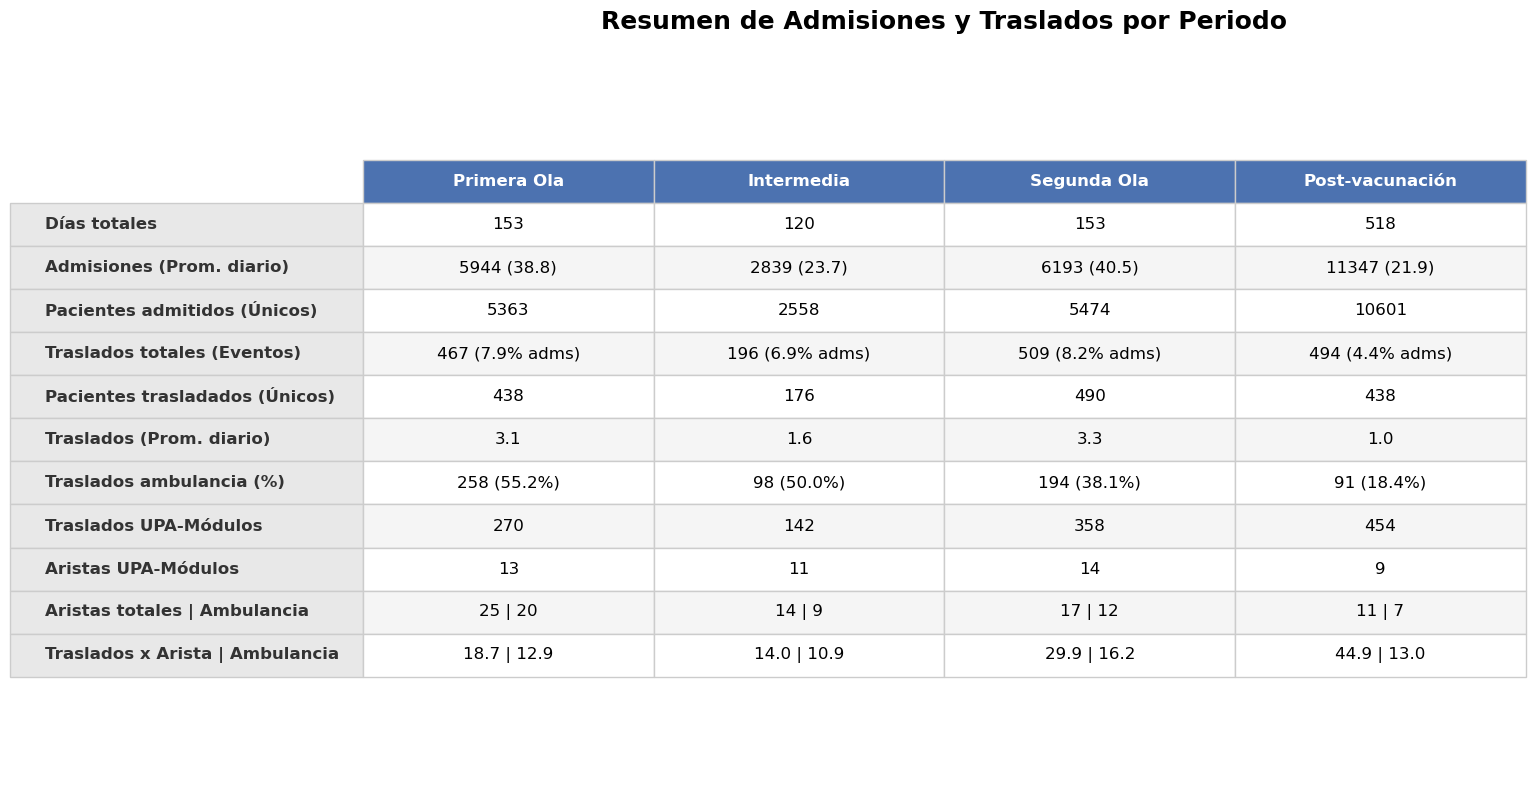

In [7]:
# ==========================================
# EXPORTACIÓN VISUAL DE LA TABLA (MATPLOTLIB)
# ==========================================
import matplotlib.pyplot as plt

# Creamos la figura y ocultamos los ejes clásicos del gráfico
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Generamos la tabla en Matplotlib
tabla_mpl = ax.table(
    cellText=tabla_resumen.values,
    rowLabels=tabla_resumen.index,
    colLabels=tabla_resumen.columns,
    loc='center',
    cellLoc='center'
)

# --- ESTILIZADO DE LA TABLA ---
# Ajustamos tamaño general de celdas y fuente
tabla_mpl.auto_set_font_size(False)
tabla_mpl.set_fontsize(12)
tabla_mpl.scale(1.2, 2.2)  # (ancho, alto) de las celdas

# Definimos paleta de colores (usamos el azul que ya venís usando)
COLOR_HEADER = '#4c72b0'
COLOR_FILA_PAR = '#f5f5f5'
COLOR_FILA_IMPAR = '#ffffff'
COLOR_INDEX = '#e8e8e8'

# Iteramos por cada celda para pintarla y darle formato
for (row, col), cell in tabla_mpl.get_celld().items():
    cell.set_edgecolor('#cccccc') # Color del borde de las celdas
    
    # Encabezados de columnas (arriba)
    if row == 0:
        cell.set_facecolor(COLOR_HEADER)
        cell.set_text_props(weight='bold', color='white')
    
    # Encabezados de filas (izquierda)
    elif col == -1:
        cell.set_facecolor(COLOR_INDEX)
        cell.set_text_props(weight='bold', color='#333333')
        cell._loc = 'left' # Alineamos el texto a la izquierda para que sea más legible
    
    # Celdas de datos (adentro)
    else:
        # Alternamos colores para efecto cebra
        if row % 2 == 0:
            cell.set_facecolor(COLOR_FILA_PAR)
        else:
            cell.set_facecolor(COLOR_FILA_IMPAR)

# Título de la tabla
plt.title("Resumen de Admisiones y Traslados por Periodo", fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Si querés guardarla automáticamente como imagen, descomentá la línea de abajo:
# fig.savefig("tabla_resumen_periodos.png", dpi=300, bbox_inches='tight')

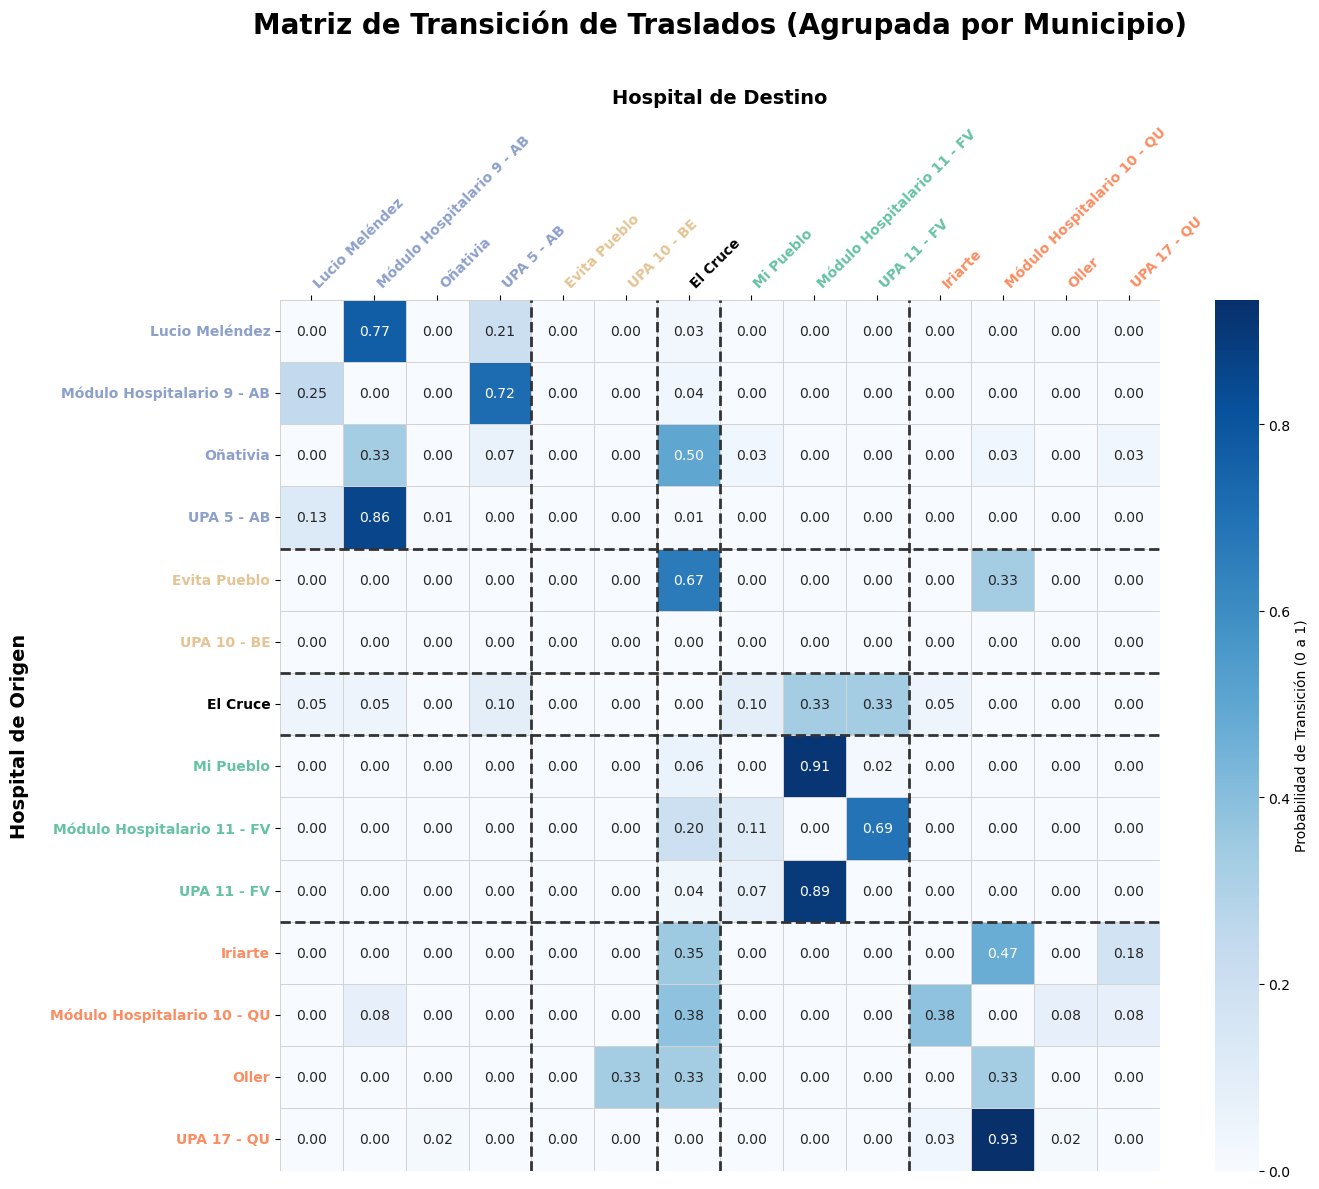

In [8]:
# ==========================================
# 8. MATRIZ DE TRANSICIÓN (AGRUPADA Y A COLOR)
# ==========================================

# 1. Recuperamos la info de los hospitales y sus municipios
# Asumimos que el df original "hospitales" todavía existe en memoria
df_meta = hospitales[['Nombre Hospital', 'municipioAbreviado', 'color']].copy()

# Nos aseguramos de que el color sea una tupla (por si viene como string)
df_meta['color'] = df_meta['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Obtenemos los hospitales que participan en los traslados
hospitales_red_set = set(df_traslados['hospital_ingreso']).union(set(df_traslados['hospital_destino']))

# Filtramos la metadata solo para los hospitales que vamos a dibujar
df_meta_red = df_meta[df_meta['Nombre Hospital'].isin(hospitales_red_set)].copy()

# 3. ¡EL PASO CLAVE! Ordenamos primero por Municipio y luego por Nombre
df_meta_red = df_meta_red.sort_values(['municipioAbreviado', 'Nombre Hospital'])

# Esta es nuestra nueva lista ordenada
orden_hospitales = df_meta_red['Nombre Hospital'].tolist()
municipios_ordenados = df_meta_red['municipioAbreviado'].tolist()

# 4. Creamos la Matriz de Contingencia y la reindexamos con el nuevo ORDEN
matriz_frecuencias = pd.crosstab(
    df_traslados['hospital_ingreso'], 
    df_traslados['hospital_destino']
).reindex(index=orden_hospitales, columns=orden_hospitales, fill_value=0)

# 5. Convertimos a Matriz de Transición (Probabilidades de cada fila suman 1)
matriz_transicion = matriz_frecuencias.div(matriz_frecuencias.sum(axis=1), axis=0).fillna(0)
# ==========================================
# DIBUJO DEL HEATMAP (SEABORN) - EJE X ARRIBA
# ==========================================
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('white')

# Dibujamos el mapa de calor
sns.heatmap(matriz_transicion, annot=True, cmap="Blues", fmt=".2f", 
            linewidths=0.5, linecolor='lightgray', 
            cbar_kws={'label': 'Probabilidad de Transición (0 a 1)'}, ax=ax)

# --- MOVER EJE X ARRIBA ---
ax.xaxis.tick_top() # Mueve los nombres de los hospitales arriba
ax.xaxis.set_label_position('top') # Mueve el texto "Hospital de Destino" arriba

# Aumentamos un poco el 'pad' del título para que no choque con los nombres de los hospitales
ax.set_title("Matriz de Transición de Traslados (Agrupada por Municipio)", fontsize=20, fontweight='bold', pad=40)
ax.set_xlabel("Hospital de Destino", fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel("Hospital de Origen", fontsize=14, fontweight='bold', labelpad=15)

# --- APLICAR COLORES A LAS ETIQUETAS DE LOS EJES ---
dict_colores = dict(zip(df_meta_red['Nombre Hospital'], df_meta_red['color']))

# Eje X (Nombres arriba)
for tick_label in ax.get_xticklabels():
    hosp_name = tick_label.get_text()
    tick_label.set_color(dict_colores.get(hosp_name, 'black'))
    tick_label.set_fontweight('bold')
    tick_label.set_rotation(45)
    # Al estar arriba, la alineación 'left' queda mejor para leer la diagonal
    tick_label.set_ha('left') 

# Eje Y (Nombres a la izquierda)
for tick_label in ax.get_yticklabels():
    hosp_name = tick_label.get_text()
    tick_label.set_color(dict_colores.get(hosp_name, 'black'))
    tick_label.set_fontweight('bold')

# --- DIBUJAR LÍNEAS SEPARADORAS ENTRE MUNICIPIOS ---
# Buscamos los índices donde cambia el municipio en la lista
cambios_municipio = [i for i in range(1, len(municipios_ordenados)) 
                     if municipios_ordenados[i] != municipios_ordenados[i-1]]

# Dibujamos una cuadrícula para marcar los bloques
for c in cambios_municipio:
    ax.axhline(c, color='#333333', lw=2, linestyle='--') # Línea horizontal
    ax.axvline(c, color='#333333', lw=2, linestyle='--') # Línea vertical

plt.tight_layout()
plt.show()


# # Opcional: Mostrar la tabla en la consola también
# matriz_transicion_display = matriz_transicion.round(3)
# display(matriz_transicion_display)

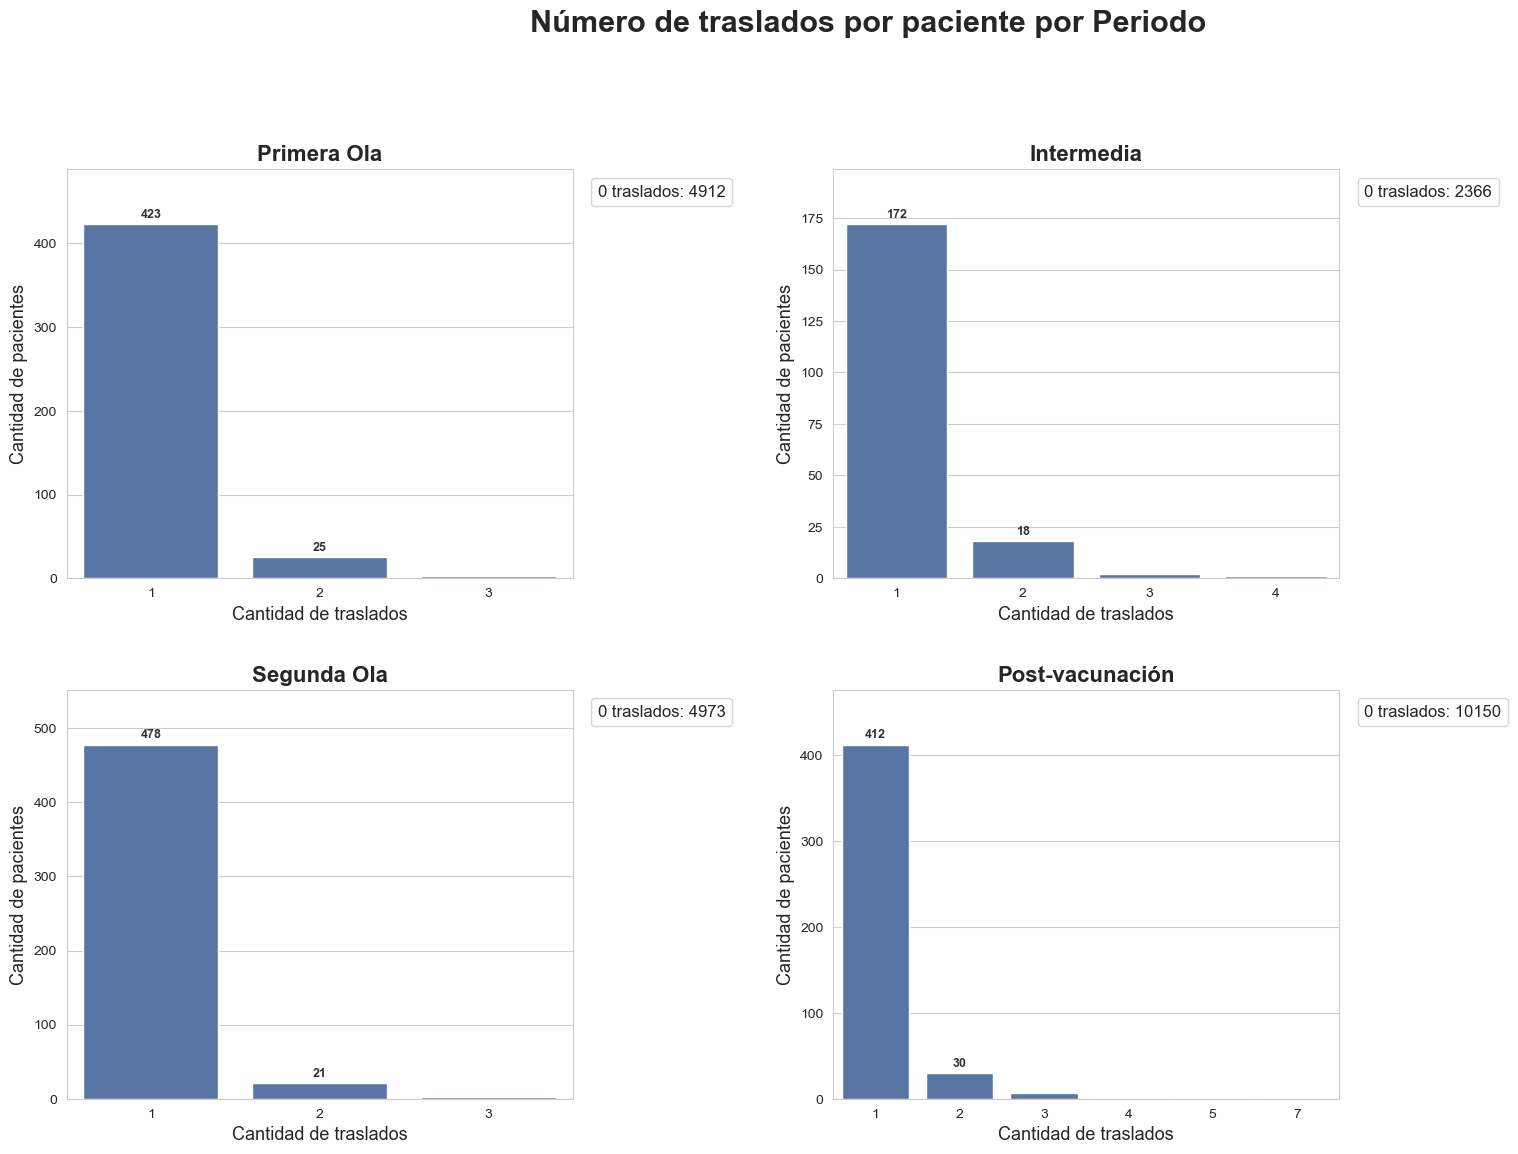

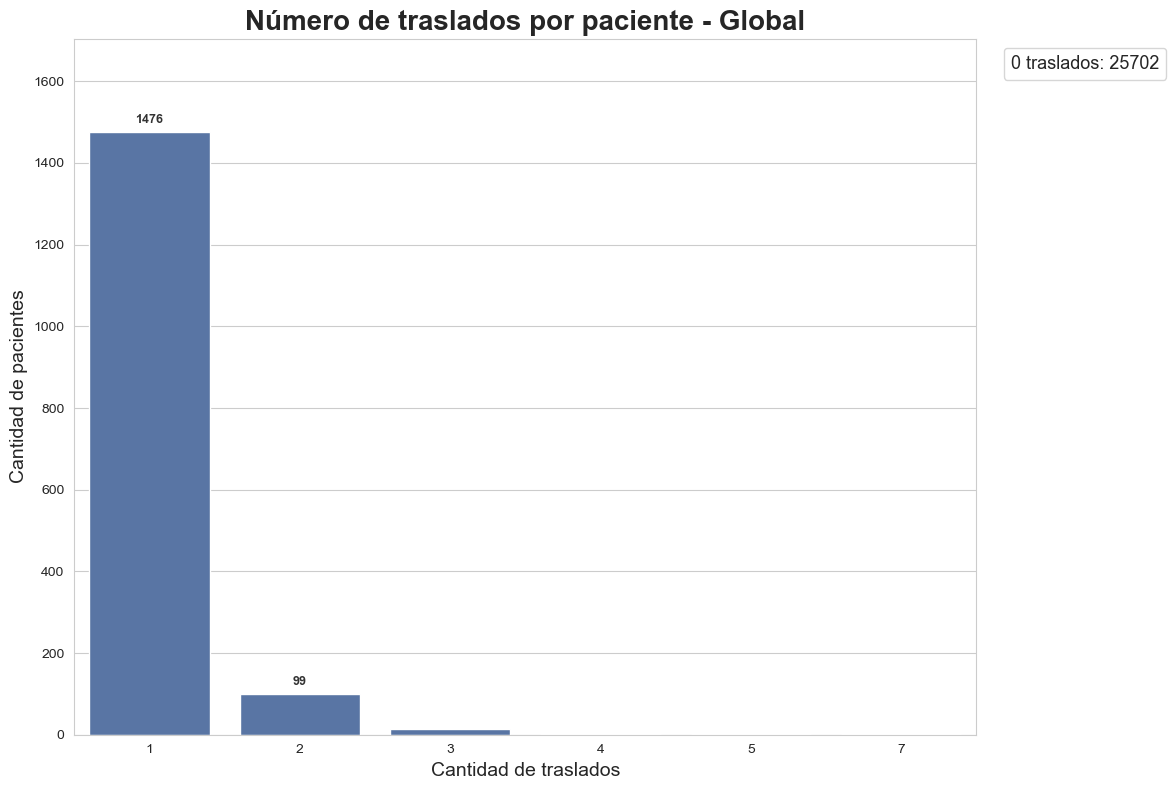

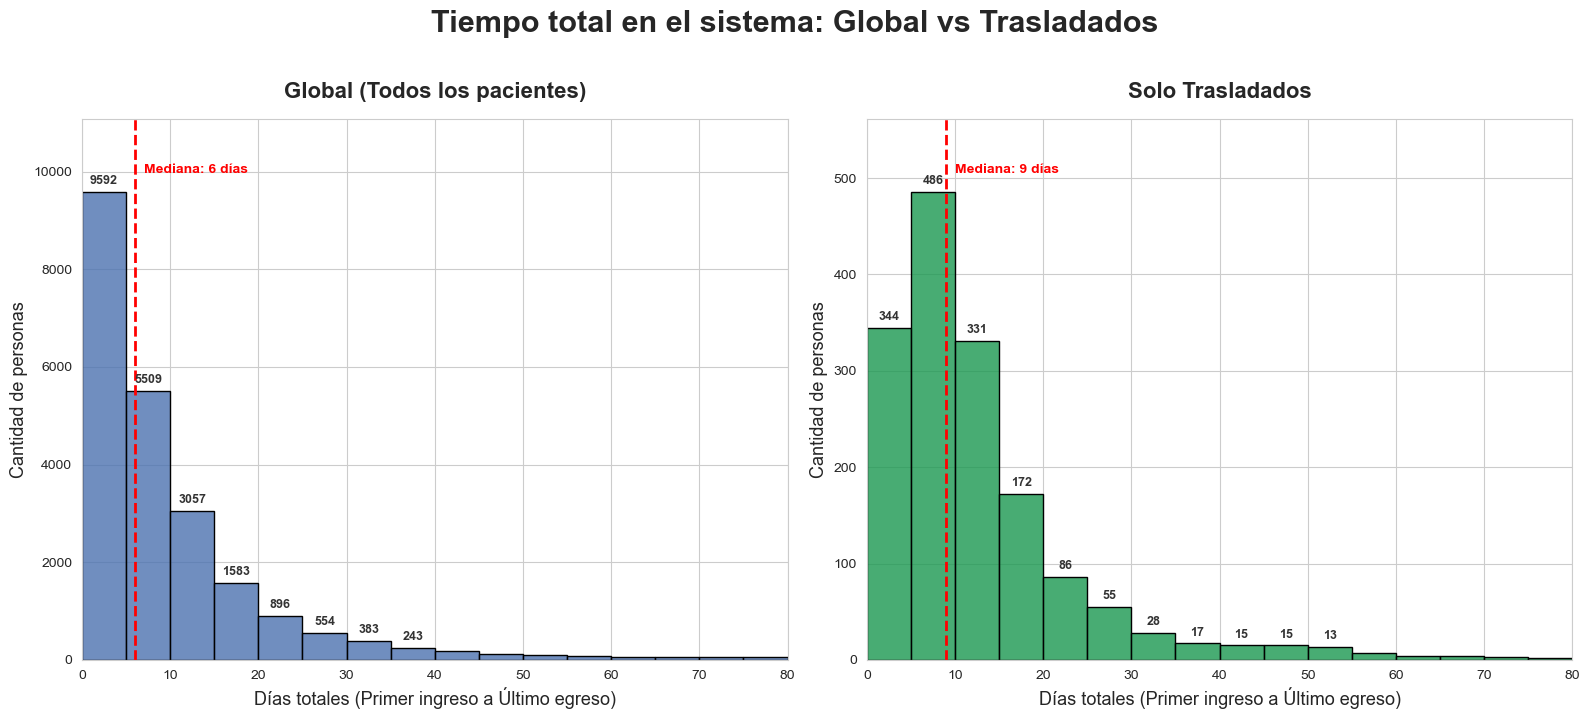

In [9]:
# ==========================================
# 9. ANÁLISIS ESTADÍSTICO Y TEMPORAL
# ==========================================


# --- 1. LIMPIEZA BASE PARA SINCRONIZAR CON LA TABLA/GRAFO ---
# Aplicamos el filtro estructural (sin self-loops, solo hospitales conocidos)
mask_validos_stats = (
    (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & 
    (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & 
    (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])
)
df_traslados_stats = df_traslados[mask_validos_stats].copy()

# --- CONFIGURACIÓN DE ESTILO ---
sns.set_style("whitegrid") 

COLOR_AZUL = '#4c72b0' 
COLOR_VERDE = '#1a9850'

# --- FUNCIÓN PARA AGREGAR VALORES SOBRE BARRAS ---
def agregar_valores(ax, apilado=False):
    max_y = ax.get_ylim()[1]
    space = max_y * 0.01 
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            y_pos = p.get_y() + height if apilado else height
            # Ocultamos el texto si la barra es muy chiquita para no superponer números
            if height >= (max_y * 0.02): 
                ax.text(p.get_x() + p.get_width() / 2.,
                        y_pos + space,
                        f'{int(height)}',
                        ha="center", va="bottom", fontsize=9, fontweight='bold', color='#333333')
            
    ax.set_ylim(0, max_y * 1.1) 

# =========================================================================
# GRÁFICO 1: NÚMERO DE TRASLADOS POR PACIENTE (SOLO TRASLADADOS)
# =========================================================================
fig1a, axes1a = plt.subplots(2, 2, figsize=(18, 12))
fig1a.patch.set_facecolor('white')
fig1a.suptitle("Número de traslados por paciente por Periodo", fontsize=22, fontweight='bold', y=0.98)
axes1a_flat = axes1a.flatten()

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes1a_flat[idx]
    
    mask_p = (pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)
    mask_t = (df_traslados_stats['fecha_egreso'] >= inicio) & (df_traslados_stats['fecha_egreso'] <= fin)
    df_t_per = df_traslados_stats[mask_t]
    
    pacientes_admitidos_per = set(pacientes[mask_p]['paciente_id'])
    pacientes_trasladados_per = set(df_t_per['paciente_id'])
    cero_traslados = len(pacientes_admitidos_per - pacientes_trasladados_per)
    
    if not df_t_per.empty:
        conteo = df_t_per.groupby('paciente_id').size().value_counts().sort_index()
        sns.barplot(x=conteo.index, y=conteo.values, color=COLOR_AZUL, ax=ax)
        agregar_valores(ax, apilado=False)
        
    ax.set_title(titulo, fontsize=16, fontweight='bold')
    ax.set_xlabel("Cantidad de traslados", fontsize=13)
    ax.set_ylabel("Cantidad de pacientes", fontsize=13)
    
    leyenda_0 = mlines.Line2D([], [], color='none', marker='None', label=f'0 traslados: {cero_traslados}')
    ax.legend(handles=[leyenda_0], loc='upper left', bbox_to_anchor=(1.02, 1), 
              frameon=True, fontsize=12, handlelength=0, handletextpad=0)

plt.tight_layout(rect=[0, 0, 0.88, 0.96], pad=3.0)

# FIGURA 1B: GLOBAL (1 GRANDE)
fig1b, ax1b = plt.subplots(figsize=(14, 8))
fig1b.patch.set_facecolor('white')

conteo_global = df_traslados_stats.groupby('paciente_id').size().value_counts().sort_index()
sns.barplot(x=conteo_global.index, y=conteo_global.values, color=COLOR_AZUL, ax=ax1b)
agregar_valores(ax1b, apilado=False)

ax1b.set_title("Número de traslados por paciente - Global", fontsize=20, fontweight='bold')
ax1b.set_xlabel("Cantidad de traslados", fontsize=14)
ax1b.set_ylabel("Cantidad de pacientes", fontsize=14)

pacientes_admitidos_global = set(pacientes['paciente_id'])
pacientes_trasladados_global = set(df_traslados_stats['paciente_id'])
cero_traslados_global = len(pacientes_admitidos_global - pacientes_trasladados_global)

leyenda_0_global = mlines.Line2D([], [], color='none', marker='None', label=f'0 traslados: {cero_traslados_global}')
ax1b.legend(handles=[leyenda_0_global], loc='upper left', bbox_to_anchor=(1.02, 1), 
            frameon=True, fontsize=13, handlelength=0, handletextpad=0)

plt.tight_layout(rect=[0, 0, 0.85, 1])

# =========================================================================
# GRÁFICO 2: TIEMPO EN EL SISTEMA HOSPITALARIO (GLOBAL VS TRASLADADOS)
# =========================================================================
# 1. Calculamos el tiempo total en el sistema para TODOS los pacientes
tiempo_trayectorias_todas = pacientes.groupby('paciente_id').agg(
    ingreso_sistema=('fecha_ingreso', 'min'),
    egreso_sistema=('fecha_egreso', 'max')
)
tiempo_trayectorias_todas['dias_en_sistema'] = (tiempo_trayectorias_todas['egreso_sistema'] - tiempo_trayectorias_todas['ingreso_sistema']).dt.days
tiempo_trayectorias_todas = tiempo_trayectorias_todas[tiempo_trayectorias_todas['dias_en_sistema'] >= 0].copy()

# 2. Separamos a los pacientes en "Trasladados"
ids_trasladados = set(df_traslados_stats['paciente_id'])
mask_trasladados = tiempo_trayectorias_todas.index.isin(ids_trasladados)

df_trasladados = tiempo_trayectorias_todas[mask_trasladados]

if not tiempo_trayectorias_todas.empty:
    # 3. Calculamos un máximo común (Percentil 99 global) para que los ejes X sean idénticos
    limite_p99_global = tiempo_trayectorias_todas['dias_en_sistema'].quantile(0.99)
    max_plot = int(limite_p99_global) if not pd.isna(limite_p99_global) else int(tiempo_trayectorias_todas['dias_en_sistema'].max())
    bins_5dias = np.arange(0, max_plot + 5, 5)

    # 4. Creamos la figura con 2 subplots (1 fila, 2 columnas)
    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
    fig2.patch.set_facecolor('white')
    fig2.suptitle("Tiempo total en el sistema: Global vs Trasladados", fontsize=22, fontweight='bold', y=1.02)

    # Configuramos los 2 gráficos en un bucle
    paneles = [
        ("Global (Todos los pacientes)", tiempo_trayectorias_todas, COLOR_AZUL),
        ("Solo Trasladados", df_trasladados, COLOR_VERDE)
    ]

    for ax, (titulo, df_subset, color) in zip(axes2, paneles):
        sns.histplot(df_subset['dias_en_sistema'], bins=bins_5dias, color=color, 
                     ax=ax, edgecolor='black', alpha=0.8)

        agregar_valores(ax, apilado=False)

        ax.set_title(titulo, fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel("Días totales (Primer ingreso a Último egreso)", fontsize=13)
        ax.set_ylabel("Cantidad de personas", fontsize=13)
        ax.set_xlim(0, max_plot)
        ax.set_xticks(np.arange(0, max_plot + 5, 10))
        
        # Agregamos una línea vertical marcando la mediana
        mediana = df_subset['dias_en_sistema'].median()
        if not pd.isna(mediana):
            ax.axvline(mediana, color='red', linestyle='dashed', linewidth=2)
            ax.text(mediana + 1, ax.get_ylim()[1]*0.9, f'Mediana: {int(mediana)} días', color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

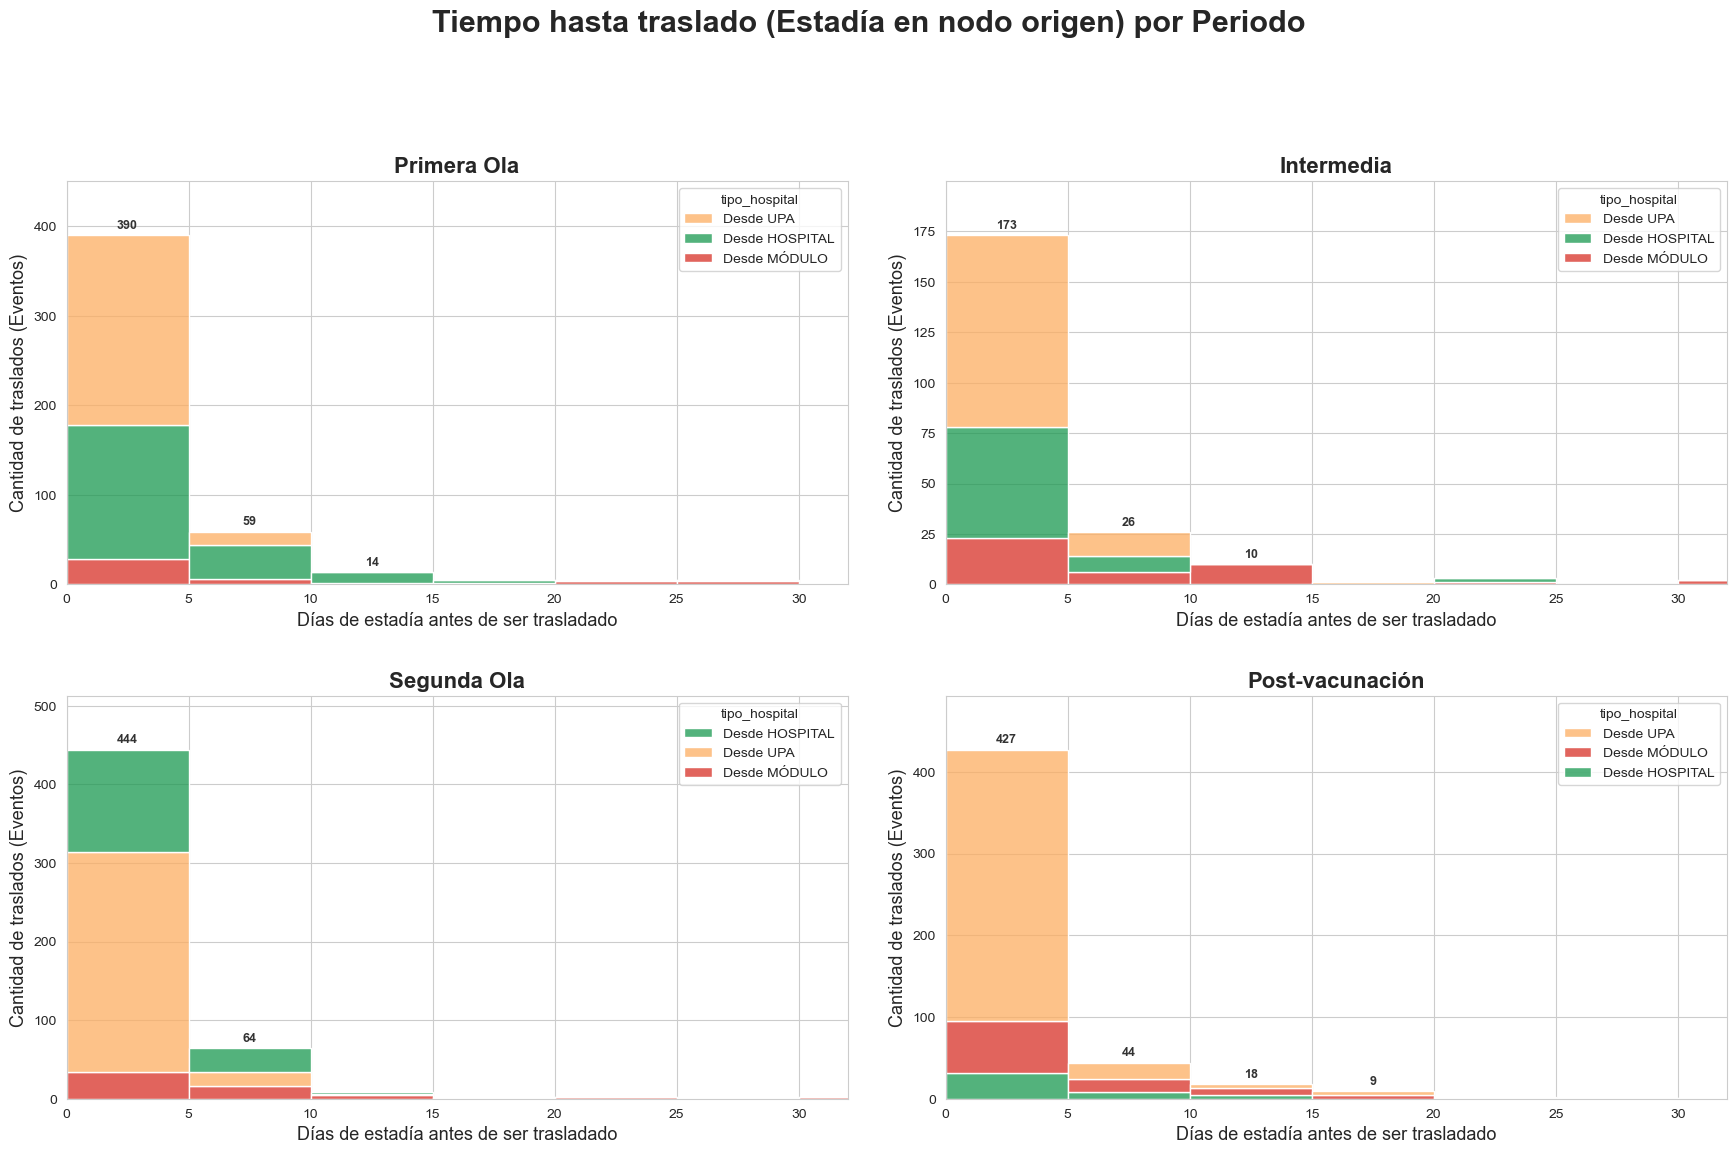

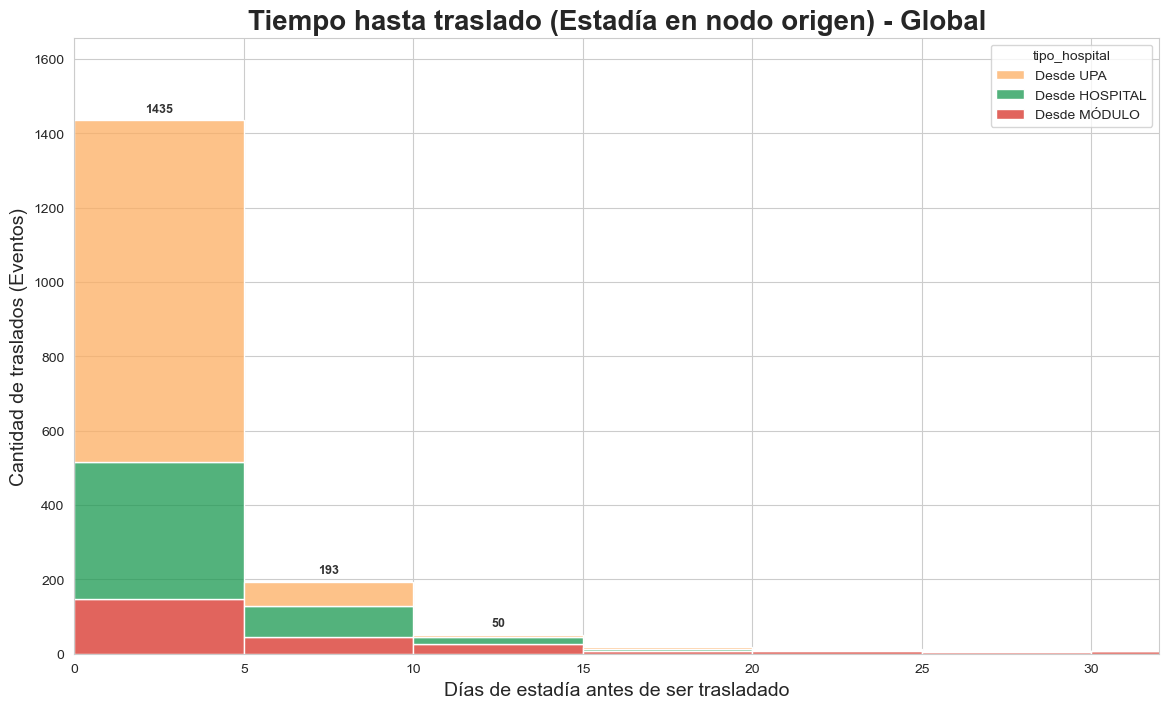

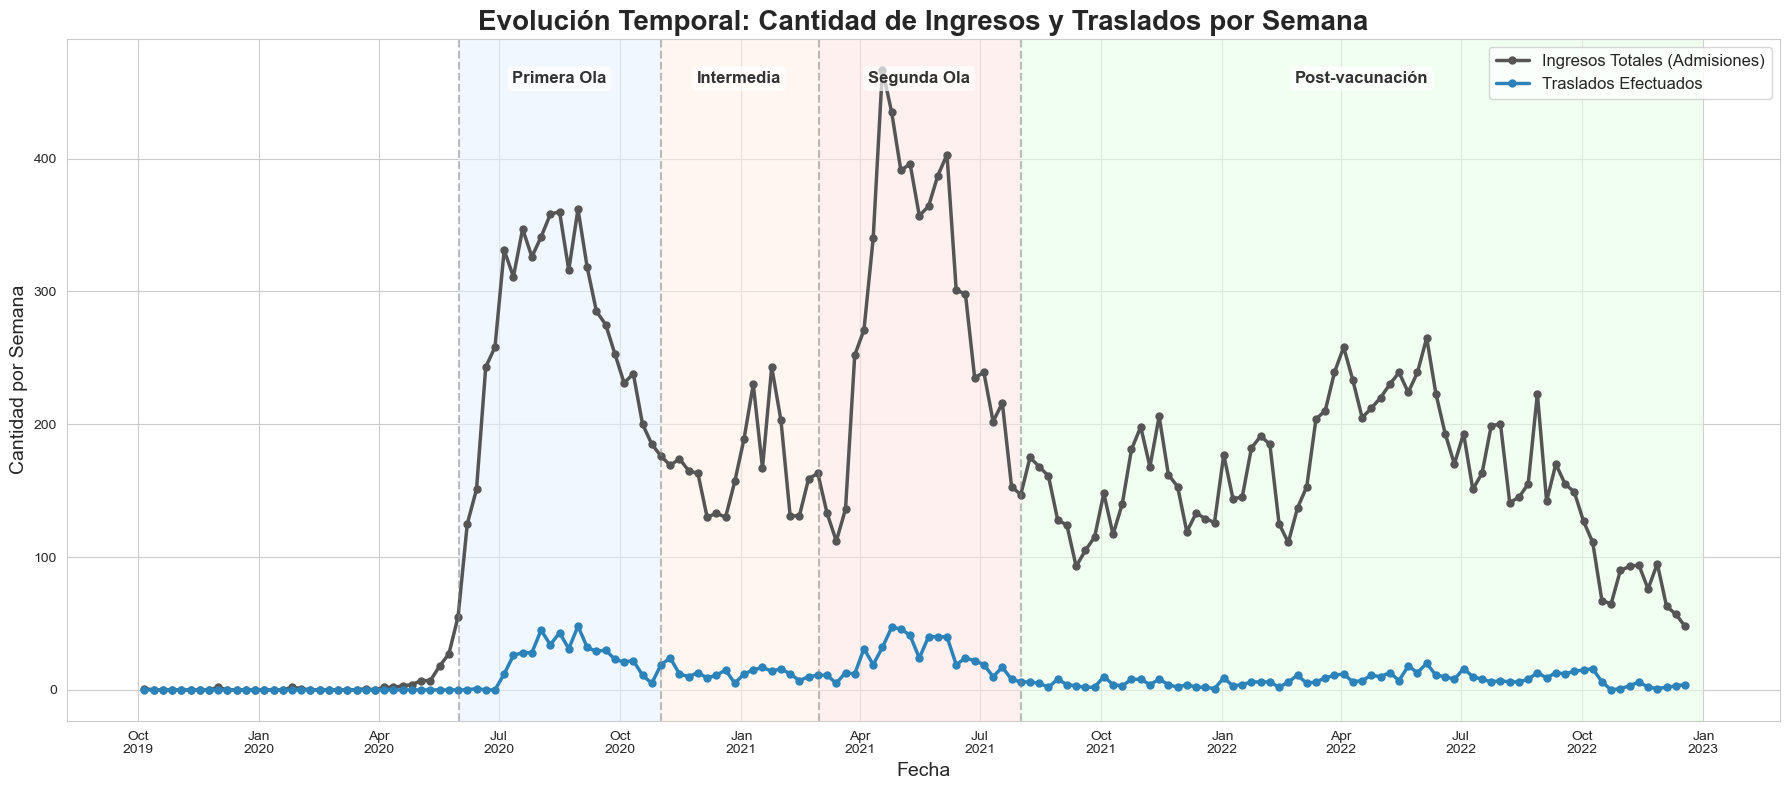

In [10]:

# --- CONFIGURACIÓN DE COLORES ---
COLOR_INGRESOS = '#555555' 
COLOR_TRASLADOS = '#2b83ba' 

colores_tipo_origen = {
    'Desde MÓDULO': '#d73027', 
    'Desde UPA': '#fdae61', 
    'Desde HOSPITAL': '#1a9850'
}

# --- NUEVA FUNCIÓN PARA BARRAS APILADAS (SOLO TOTALES) ---
def agregar_valores_totales(ax):
    max_y_per_x = {}
    # 1. Encontramos el techo (la altura total) para cada posición en el eje X
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            x_center = p.get_x() + p.get_width() / 2.
            y_top = p.get_y() + height
            
            # Guardamos el punto más alto de la pila para esa coordenada X
            if x_center not in max_y_per_x or y_top > max_y_per_x[x_center]:
                max_y_per_x[x_center] = y_top

    # 2. Dibujamos un solo texto en la cima de cada barra
    max_y_axis = ax.get_ylim()[1]
    space = max_y_axis * 0.01 
    
    for x_center, total_height in max_y_per_x.items():
        if total_height >= (max_y_axis * 0.02): # Filtro para no ensuciar con barras casi invisibles
            ax.text(x_center, total_height + space,
                    f'{int(total_height)}',
                    ha="center", va="bottom", fontsize=9, fontweight='bold', color='#333333')
            
    ax.set_ylim(0, max_y_axis * 1.1)

# =========================================================================
# GRÁFICO 3: TIEMPO HASTA TRASLADO (DÍAS EN EL NODO ORIGEN)
# =========================================================================
df_movimientos = df_traslados_stats.copy()
df_movimientos['dias_antes_traslado'] = (df_movimientos['fecha_egreso'] - df_movimientos['fecha_ingreso']).dt.days

# Filtramos posibles errores de carga (fechas negativas)
df_movimientos = df_movimientos[df_movimientos['dias_antes_traslado'] >= 0]

def clasificar_hospital(nombre):
    nombre_norm = str(nombre).upper()
    if 'MODULO' in nombre_norm or 'MÓDULO' in nombre_norm: return 'Desde MÓDULO'
    elif 'UPA' in nombre_norm: return 'Desde UPA'
    else: return 'Desde HOSPITAL'

df_movimientos['tipo_hospital'] = df_movimientos['hospital_ingreso'].apply(clasificar_hospital)

# Calculamos límite para el eje X
if not df_movimientos.empty:
    limite_p99_nodo = df_movimientos['dias_antes_traslado'].quantile(0.99)
    max_plot_nodo = int(limite_p99_nodo) if not pd.isna(limite_p99_nodo) else int(df_movimientos['dias_antes_traslado'].max())
    bins_mov_5 = np.arange(0, max_plot_nodo + 5, 5)
else:
    max_plot_nodo = 30
    bins_mov_5 = np.arange(0, 35, 5)

# FIGURA 3A: PERIODOS (2x2)
fig3a, axes3a = plt.subplots(2, 2, figsize=(18, 12))
fig3a.patch.set_facecolor('white')
fig3a.suptitle("Tiempo hasta traslado (Estadía en nodo origen) por Periodo", fontsize=22, fontweight='bold', y=0.98)
axes3a_flat = axes3a.flatten()

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes3a_flat[idx]
    
    mask_m = (df_movimientos['fecha_egreso'] >= inicio) & (df_movimientos['fecha_egreso'] <= fin)
    df_m_per = df_movimientos[mask_m]
    
    if not df_m_per.empty:
        sns.histplot(data=df_m_per, x='dias_antes_traslado', hue='tipo_hospital', 
                     palette=colores_tipo_origen, multiple='stack', bins=bins_mov_5, 
                     ax=ax, edgecolor='white')
        
        # Usamos la función nueva acá
        agregar_valores_totales(ax)
        
    ax.set_title(titulo, fontsize=16, fontweight='bold')
    ax.set_xlabel("Días de estadía antes de ser trasladado", fontsize=13)
    ax.set_ylabel("Cantidad de traslados (Eventos)", fontsize=13)
    ax.set_xlim(0, max_plot_nodo)

plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)

# FIGURA 3B: GLOBAL (1 GRANDE)
fig3b, ax3b = plt.subplots(figsize=(14, 8))
fig3b.patch.set_facecolor('white')

if not df_movimientos.empty:
    sns.histplot(data=df_movimientos, x='dias_antes_traslado', hue='tipo_hospital', 
                 palette=colores_tipo_origen, multiple='stack', bins=bins_mov_5, 
                 ax=ax3b, edgecolor='white')

    # Y usamos la función nueva acá
    agregar_valores_totales(ax3b)

ax3b.set_title("Tiempo hasta traslado (Estadía en nodo origen) - Global", fontsize=20, fontweight='bold')
ax3b.set_xlabel("Días de estadía antes de ser trasladado", fontsize=14)
ax3b.set_ylabel("Cantidad de traslados (Eventos)", fontsize=14)
ax3b.set_xlim(0, max_plot_nodo)


# =========================================================================
# GRÁFICO 4: EVOLUCIÓN TEMPORAL
# =========================================================================
fig4, ax4 = plt.subplots(figsize=(18, 8))
fig4.patch.set_facecolor('white')

ingresos_ts = pacientes.set_index('fecha_ingreso').resample('W').size().rename('Ingresos Totales')
traslados_ts = df_traslados_stats.set_index('fecha_egreso').resample('W').size().rename('Traslados')
df_ts = pd.concat([ingresos_ts, traslados_ts], axis=1).fillna(0)

# Graficamos las líneas (por semana)
ax4.plot(df_ts.index, df_ts['Ingresos Totales'], label='Ingresos Totales (Admisiones)', 
         color=COLOR_INGRESOS, linewidth=2.5, marker='o', markersize=5)
ax4.plot(df_ts.index, df_ts['Traslados'], label='Traslados Efectuados', 
         color=COLOR_TRASLADOS, linewidth=2.5, marker='o', markersize=5)

# Dibujamos las franjas de fondo para identificar las etapas
colores_fondo = ['#e6f2ff', '#fff0e6', '#ffe6e6', '#e6ffe6'] 
for i, (titulo, inicio, fin) in enumerate(periodos):
    f_ini = pd.to_datetime(inicio)
    f_fin = pd.to_datetime(fin)
    
    ax4.axvspan(f_ini, f_fin, color=colores_fondo[i % len(colores_fondo)], alpha=0.6)
    ax4.axvline(f_ini, color='gray', linestyle='--', alpha=0.5)
    
    y_max = ax4.get_ylim()[1]
    mid_point = f_ini + (f_fin - f_ini) / 2
    ax4.text(mid_point, y_max * 0.95, titulo, ha='center', va='top', 
             fontsize=12, fontweight='bold', color='#333333',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

ax4.set_title("Evolución Temporal: Cantidad de Ingresos y Traslados por Semana", fontsize=20, fontweight='bold')
ax4.set_xlabel("Fecha", fontsize=14)
ax4.set_ylabel("Cantidad por Semana", fontsize=14)

ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

ax4.legend(loc='upper right', fontsize=12, frameon=True)
plt.tight_layout()

plt.show()

In [ ]:
# ## prueba para ver que tal evita pueblo
# inicio = '2020-11-01'
# fin = '2021-02-28'


# df_periodo = pacientes[
#     (pacientes['fecha_egreso'] >= inicio) &
#     (pacientes['fecha_egreso'] <= fin)
# ].copy()

# df_ingresos_upa10 = df_periodo[
#     (df_periodo['hospital_origen'] == 'UPA 10 - BE')
# ].copy()

# # df_evita_a_modulo = df_periodo[
# #     (df_periodo['hospital_ingreso'] == 'Evita Pueblo') &
# #     (df_periodo['hospital_destino'] == 'Módulo Hospitalario 10 - QU')
# # ].copy()

# cantidad = len(df_ingresos_upa10)
# print("Cantidad de traslados:", cantidad)

# df_ingresos_upa10

# # ==========================================
# # 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# # ==========================================

# # # Limpieza profunda de strings
# # pacientes['hospital_origen'] = pacientes['hospital_origen'].astype(str).str.strip()
# # hospitales['Nombre Hospital'] = hospitales['Nombre Hospital'].astype(str).str.strip()

# # # Verificamos si hay nombres que "parecen" iguales pero no lo son
# # nombres_pacientes = set(pacientes['hospital_origen'].unique())
# # nombres_coordenadas = set(hospitales['Nombre Hospital'].unique())

# # print(f"Hospitales en Excel Pacientes: {len(nombres_pacientes)}")
# # print(f"Hospitales en CSV Coordenadas: {len(nombres_coordenadas)}")

# # # ¿Qué hospitales están en pacientes pero NO en el archivo de coordenadas?
# # # (Si no están en coordenadas, el gráfico los ignora y perdés esos ingresos)
# # huerfanos = nombres_pacientes - nombres_coordenadas
# # if huerfanos:
# #     print(f"⚠️ Alerta: Estos hospitales no tienen coordenadas: {huerfanos}")

# def check_ingresos_reales(df, inicio, fin):
#     mask = (df['fecha_ingreso'] >= inicio) & (df['fecha_ingreso'] <= fin)
#     conteo = df[mask]['hospital_origen'].value_counts()
#     return conteo

# # Probemos con el primer periodo
# inicio_w1, fin_w1 = '2020-06-01', '2020-10-31'
# resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

# print(f"--- Ingresos Totales (Wave 1) ---")
# print(resumen_w1.head(10)) 
# print(f"Total general periodo: {resumen_w1.sum()}")

# # Probemos con el 2do periodo
# inicio_w1, fin_w1 = '2020-11-01', '2021-02-28'
# resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

# print(f"--- Ingresos Totales (Wave 1) ---")
# print(resumen_w1.head(10)) 
# print(f"Total general periodo: {resumen_w1.sum()}")


# # Probemos con el 3er periodo
# inicio_w1, fin_w1 = '2021-03-01', '2021-07-31'
# resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

# print(f"--- Ingresos Totales (Wave 1) ---")
# print(resumen_w1.head(10)) 
# print(f"Total general periodo: {resumen_w1.sum()}")


# # Probemos con el 4to periodo
# inicio_w1, fin_w1 = '2021-08-01', '2022-12-31'
# resumen_w1 = check_ingresos_reales(pacientes, inicio_w1, fin_w1)

# print(f"--- Ingresos Totales (Wave 1) ---")
# print(resumen_w1.head(10)) 
# print(f"Total general periodo: {resumen_w1.sum()}")

In [ ]:
# paciente_testigo = 'WN04'
# display(pacientes[pacientes['paciente_id'] == paciente_testigo][['fecha_ingreso', 'hospital_origen', 'motivo_egreso', 'fecha_egreso', 'hospital_destino', 'dias_traslado', 'riesgo_clinico']])

# # Ver las 5 trayectorias con más traslados
# display(df_trayectoria.sort_values('cantidad_traslados', ascending=False).head(5))

In [ ]:
# # Vamos a ver si hay pacientes con múltiples ingresos el mismo día o muy cerca
# duplicados_potenciales = pacientes.groupby(['paciente_id', 'fecha_ingreso']).size()
# duplicados_potenciales = duplicados_potenciales[duplicados_potenciales > 1]

# if not duplicados_potenciales.empty:
#     print(f"Cuidado: Hay {len(duplicados_potenciales)} casos de IDs con múltiples registros en la misma fecha.")
#     # Esto podría estar inflando tus números de ingresos.

In [ ]:
# hosp_ruido = 'Oller' # <--- CAMBIAR POR EL QUE TE DE MAL
# periodo_inicio = '2020-06-01'
# periodo_fin = '2020-10-31'

# # 1. Filtramos pacientes en ese hospital y fecha
# test_df = pacientes[
#     (pacientes['hospital_origen'] == hosp_ruido) & 
#     (pacientes['fecha_ingreso'] >= periodo_inicio) & 
#     (pacientes['fecha_ingreso'] <= periodo_fin)
# ]

# print(f"Auditoría para {hosp_ruido}:")
# print(f"Registros encontrados: {len(test_df)}")
# print(f"Pacientes únicos: {test_df['paciente_id'].nunique()}")

# # Si Registros > Pacientes únicos, tenés re-ingresos o duplicados que te inflan el número.